# Low-rank RNNs, end to end

## tl;dr

This notebook follows two rank-two networks as separate experiments.

- **Network A** starts from random weights and is trained on the literal
  fixed-delay task. It solves the task with a coupled oscillatory trajectory.
- **Network B** starts from the covariance structure suggested in the
  handout and is trained on dense frequencies and randomized delays. It
  develops separately readable persistent and transient modes.

Each network is analyzed with the same pipeline:

**train → identify dynamics → fit its post-training six-dimensional
loading Gaussian → test finite Gaussian RNN samples → test two reduced
circuits → compare behavior.**

The two reduced circuits answer different questions:

1. The **full-covariance Gaussian circuit** uses the fitted loading means
   and every entry of the fitted covariance.
2. The **handout diagonal circuit** uses that same network's fitted
   \(\operatorname{Cov}(n_r,m_r)\), \(\operatorname{Cov}(n_r,I)\), and
   \(\operatorname{Cov}(w,m_r)\), plus the fitted \(m_r\) and \(I\)
   variances. It sets loading means, cross-mode couplings, and basis
   cross-covariances to zero.

The observed contrast is strong. For Network A, the full-covariance
circuit reaches MSE \(0.0180\), while the diagonal circuit loses the
rotation and reaches \(0.9847\). For Network B, the corresponding
worst-delay scores are \(0.0053\) and \(0.0070\): both preserve the
persistent/transient computation qualitatively, but the complete fit is
more accurate.

The paper coefficients used to initialize Network B, Network A's fitted
covariance, and Network B's fitted covariance remain three distinct
objects throughout. The numerical summary at the end is generated from
the executed cells.

## 0. Setup and shared conventions

We use the repository's `LowRankRNN` throughout:

\[
\tau \dot x
= -x + \frac{1}{N}MN^\top \tanh(x) + Iu,
\qquad
z = \frac{1}{N}w^\top\tanh(x).
\]

`M` and `N` have shape \(N\times R\), so changing `rank=R` is the only
model change between the exercises. Forward Euler uses
\(\Delta t/\tau=20/100=0.2\). Only `m` and `n` train; `I` and `w` remain
fixed. The readout starts with standard deviation 4 so its finite-population
signal is visible without making it trainable.

### Notation fixes from the handout

- A standard Gaussian average has prefactor \(1/\sqrt{2\pi}\), not
  \(1/(2\pi)\).
- The rank-one variance is a function of the **filtered input** \(v\), not
  the instantaneous input \(u\).
- Mean-field \(\kappa\) is the coefficient in \(x\approx M\kappa+Iv\);
  it is obtained with a pseudoinverse. A unit-axis projection
  \(m^\top x/\lVert m\rVert\) has a different scale.
- The handout omits the reduced readout. We include it because otherwise the
  reduced circuit cannot be tested on the task.

In [1]:
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from low_rank_rnn import analysis, mean_field, plotting
from low_rank_rnn.data import perceptual_decision_making as decision_task
from low_rank_rnn.data import working_memory as memory_task
from low_rank_rnn.model import LowRankRNN, persistent_transient_rnn
from low_rank_rnn.training import (
    decision_accuracy,
    train_model,
    train_variable_delay,
)

plotting.set_plot_style()
BASE_SEED = 2026
NUM_UNITS = 128
TASK_MSE_THRESHOLD = 5e-3
NUM_GAUSSIAN_NETWORKS = 10
REPORT_FIGURE_DIRECTORY = Path("report/figures")


def save_report_figure(figure: plt.Figure, filename: str) -> Path:
    """Save a notebook figure as a vector PDF for the LaTeX report."""
    REPORT_FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
    output_path = REPORT_FIGURE_DIRECTORY / filename
    figure.savefig(output_path, format="pdf")
    return output_path


## 1. Rank-one perceptual decision-making

### 1.1 Generate the noisy evidence

Each 75-step trial draws one signed strength

\[
\bar{\mu} \in \pm 0.032\{1,2,4,8,16\},
\qquad
y=\operatorname{sign}(\bar{\mu}),
\]

and independent noise \(\xi(t)\sim\mathcal N(0,0.03^2)\). The stimulus is
present for \(5\le t\le45\); the final 15 steps form the decision window.
Weak evidence can be comparable to one instantaneous noise sample, so the
network must integrate across time.

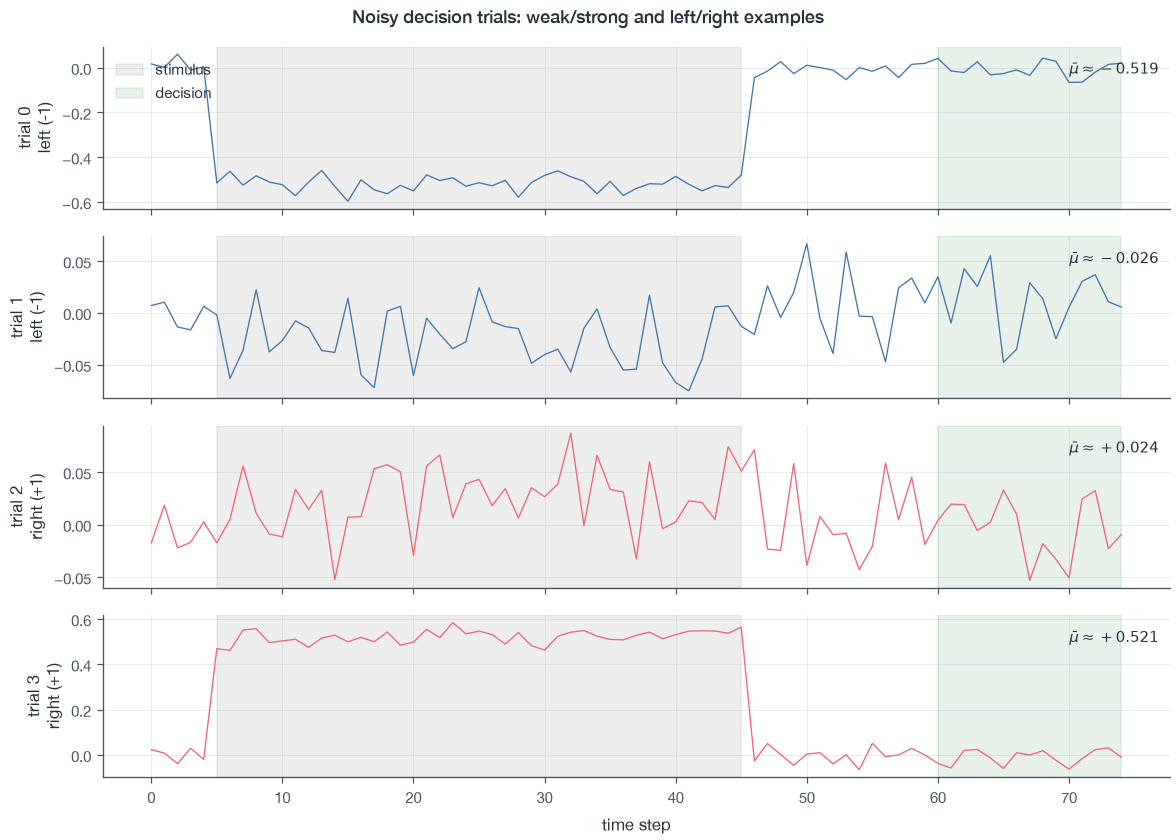

Allowed signed strengths: [-0.512 -0.256 -0.128 -0.064 -0.032  0.032  0.064  0.128  0.256  0.512]
Input shape: (80, 75) label shape: (80,)


In [2]:
preview_inputs, preview_labels = decision_task.generate_trials(
    num_trials=80,
    rng=np.random.default_rng(BASE_SEED),
)
preview_means = decision_task.mean_stimulus(preview_inputs)
preview_indices = decision_task.representative_trial_indices(
    preview_inputs,
    preview_labels,
)

rank1_decision_trials_figure, _ = plotting.plot_decision_trials(
    preview_inputs[preview_indices],
    preview_labels[preview_indices],
    mean_stimuli=preview_means[preview_indices],
)
save_report_figure(
    rank1_decision_trials_figure,
    "rank1-decision-task-trials.pdf",
)
plt.show()

print(
    "Allowed signed strengths:",
    np.round(np.sort(decision_task.STIMULUS_STRENGTHS), 3),
)
print("Input shape:", preview_inputs.shape, "label shape:", preview_labels.shape)


### 1.2 Train the shared model at rank one

The low-rank multiplication is performed as
\(m[n^\top\phi(x)/N]\), so the code never materializes the \(N\times N\)
recurrent matrix. Training minimizes MSE only over the final 15 steps,
with Adam, learning rate \(5\times10^{-3}\), and batches of 32.

The repository helper calls one pass over the fixed training set an *epoch*.
Because there are several batches per epoch, the number of optimizer updates is
`epochs × ceil(num_trials / batch_size)`.

In [3]:
RANK1_DECISION_STEPS = 15
RANK1_TRAIN_TRIALS = 200
RANK1_EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 5e-3

rank1_train_inputs, rank1_train_labels = decision_task.generate_trials(
    num_trials=RANK1_TRAIN_TRIALS,
    rng=np.random.default_rng(BASE_SEED + 1),
)
rank1_test_inputs, rank1_test_labels = decision_task.generate_trials(
    num_trials=256,
    rng=np.random.default_rng(BASE_SEED + 2),
)

torch.manual_seed(BASE_SEED)
rank1_model = LowRankRNN(n_units=NUM_UNITS, rank=1)
fixed_input_before = rank1_model.I.clone()
fixed_readout_before = rank1_model.w.clone()
rank1_losses = train_model(
    rank1_model,
    torch.as_tensor(rank1_train_inputs, dtype=torch.float32),
    torch.as_tensor(rank1_train_labels, dtype=torch.float32),
    epochs=RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=RANK1_DECISION_STEPS,
    log_every=100,
)

# The rank-one factorization is sign-indeterminate: flipping both m and n
# leaves the recurrent connectivity unchanged. Orient it so positive latent
# activity maps to the +1 (red/right) readout throughout the notebook.
with torch.no_grad():
    m_centered = rank1_model.m[:, 0] - rank1_model.m[:, 0].mean()
    w_centered = rank1_model.w - rank1_model.w.mean()
    if torch.dot(m_centered, w_centered) < 0:
        rank1_model.m[:, 0].mul_(-1)
        rank1_model.n[:, 0].mul_(-1)

rank1_outputs, rank1_states = analysis.run_model(rank1_model, rank1_test_inputs)
rank1_decisions = analysis.decision_values(
    rank1_outputs,
    RANK1_DECISION_STEPS,
)
rank1_test_mse, _ = analysis.regression_metrics(
    rank1_decisions,
    rank1_test_labels,
)
rank1_accuracy = float(
    np.mean(np.where(rank1_decisions >= 0, 1, -1) == rank1_test_labels)
)
rank1_updates = RANK1_EPOCHS * ceil(RANK1_TRAIN_TRIALS / BATCH_SIZE)

assert rank1_losses[-1] < 5e-2
assert torch.equal(rank1_model.I, fixed_input_before)
assert torch.equal(rank1_model.w, fixed_readout_before)

print(f"Optimizer updates:      {rank1_updates}")
print(f"Final training loss:    {rank1_losses[-1]:.6f}  (target < 0.05)")
print(f"Held-out decision MSE: {rank1_test_mse:.6f}")
print(f"Held-out sign accuracy:{rank1_accuracy:8.1%}")


Epoch 100: loss=0.000300


Epoch 200: loss=0.000121


Epoch 300: loss=0.000088
Optimizer updates:      2100
Final training loss:    0.000088  (target < 0.05)
Held-out decision MSE: 0.000048
Held-out sign accuracy:  100.0%


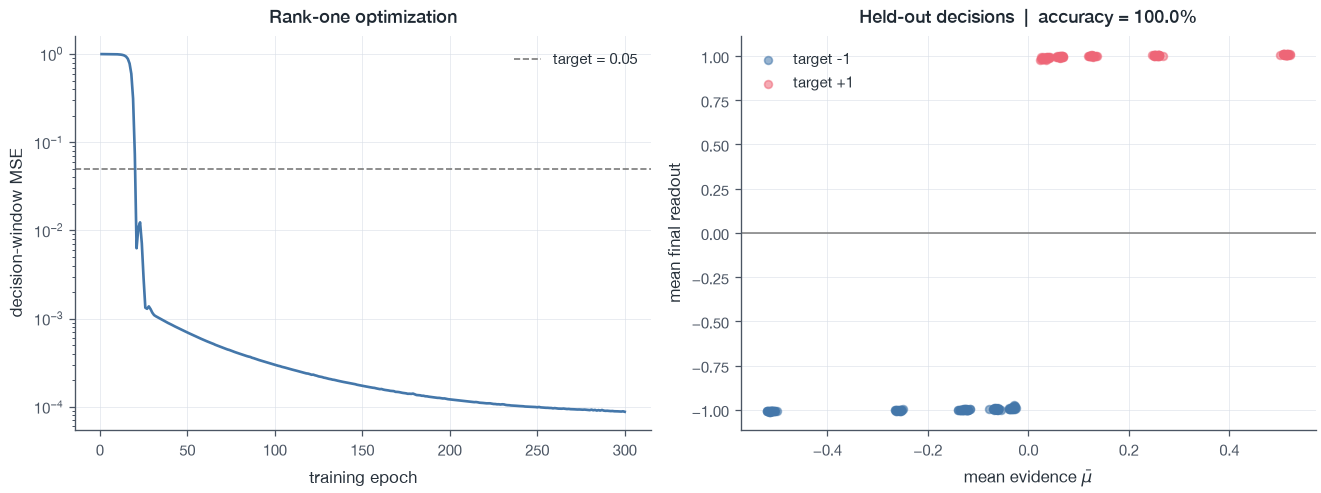

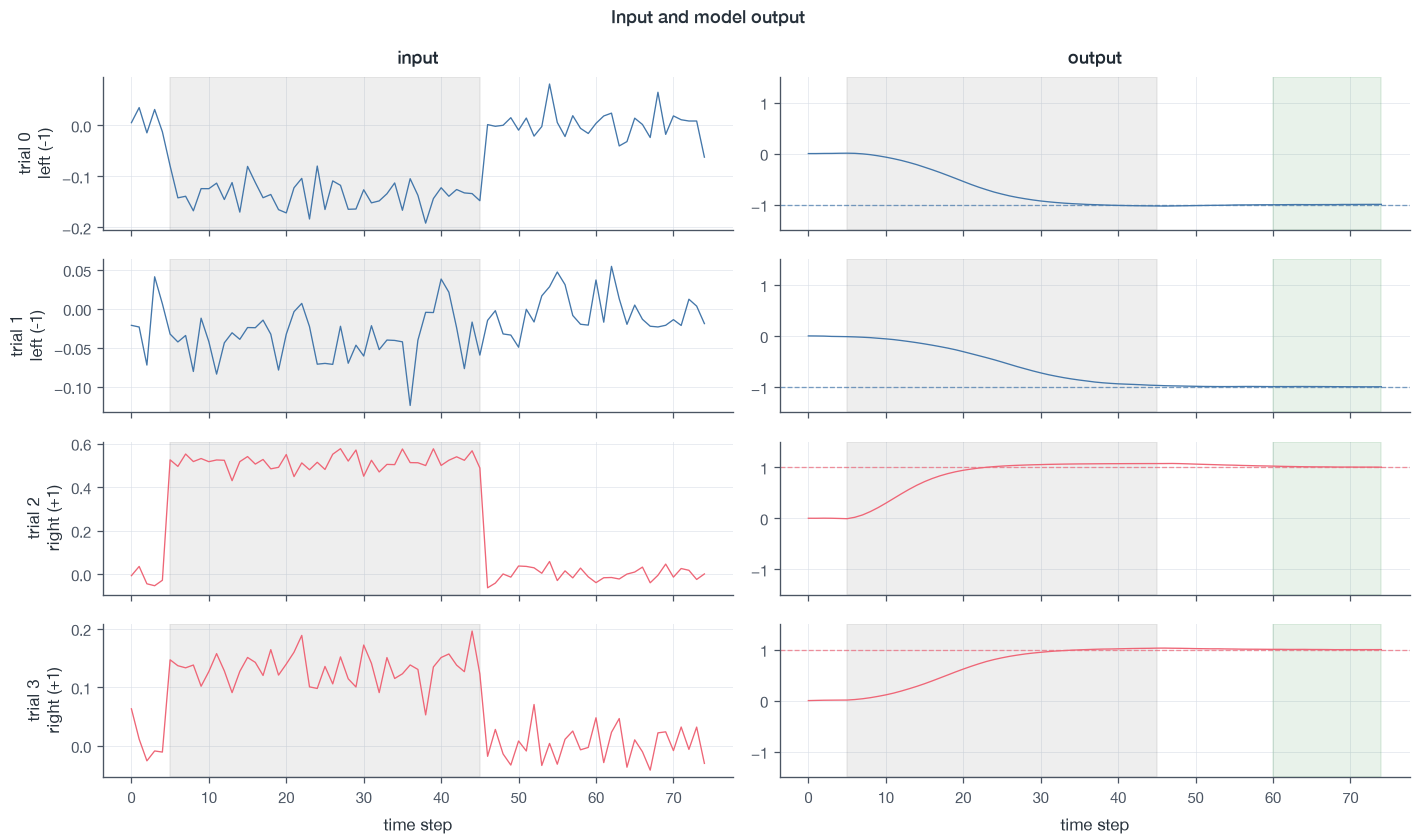

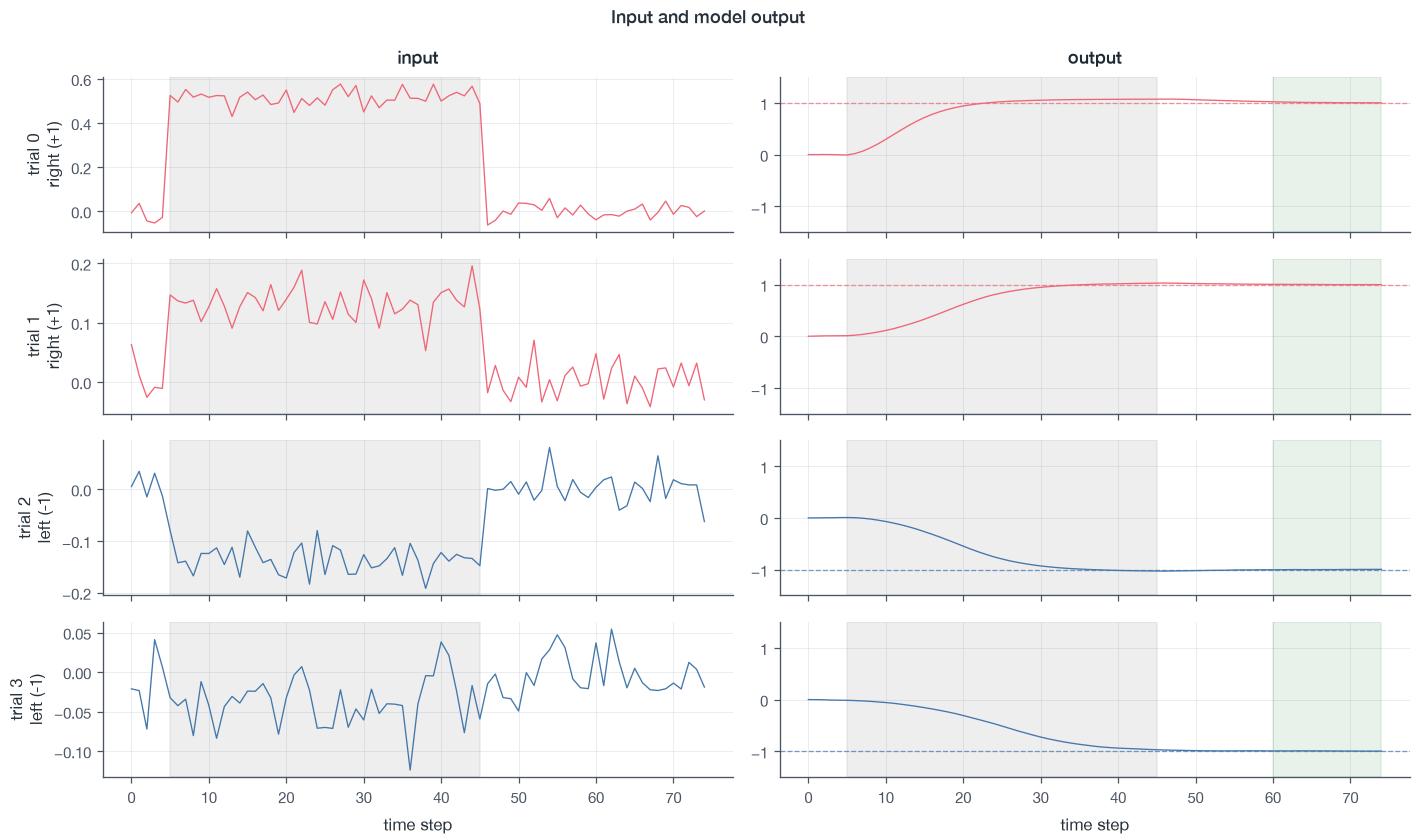

In [4]:
stimulus_estimates = decision_task.mean_stimulus(rank1_test_inputs)
rank1_training_summary_figure, _ = plotting.plot_decision_summary(
    rank1_losses,
    stimulus_estimates,
    rank1_decisions,
    rank1_test_labels,
    accuracy=rank1_accuracy,
    loss_threshold=5e-2,
)
save_report_figure(
    rank1_training_summary_figure,
    "rank1-training-summary.pdf",
)
plt.show()

positive_examples = np.flatnonzero(rank1_test_labels > 0)[:2]
negative_examples = np.flatnonzero(rank1_test_labels < 0)[:2]
rank1_examples = np.concatenate((negative_examples, positive_examples))
rank1_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_examples],
    rank1_test_labels[rank1_examples],
    rank1_outputs[rank1_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_input_output_figure,
    "rank1-input-output-examples.pdf",
)
plt.show()

rank1_training_examples = np.concatenate((positive_examples, negative_examples))
rank1_training_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_training_examples],
    rank1_test_labels[rank1_training_examples],
    rank1_outputs[rank1_training_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_training_input_output_figure,
    "rank1-training-input-output.pdf",
)
plt.show()


### 1.3 Connectivity explains the computation

A neuron is one point in four-dimensional loading space
\((I,n,m,w)\). Three cross-covariances form the useful path:

1. \(\operatorname{Cov}(n,I)\) routes the input into the recurrent latent.
2. \(\operatorname{Cov}(m,n)\) feeds that latent back into itself.
3. \(\operatorname{Cov}(m,w)\) maps the recurrent state to the output.

The signs of the first and third terms may both flip: replacing
\(m\to-m,\ n\to-n\) leaves \(J=mn^\top/N\) unchanged. To remove that visual
ambiguity, we orient the equivalent factorization so
\(\operatorname{Cov}(m,w)>0\): positive latent activity points toward the
red/right \((+1)\) choice, and negative latent activity toward the blue/left
\((-1)\) choice. The invariant story remains the complete input → recurrence
→ readout path, not one loading vector's raw sign.

For comparison, the handout's paper circuit uses
\(\sigma_{mn}=1.4,\sigma_{nI}=2.6,\sigma_{mw}=2.1\). With this sign
convention, the run has approximately
\((1.59,0.65,2.04)\): the recurrent and readout couplings closely match,
while its fitted input coupling is weaker.

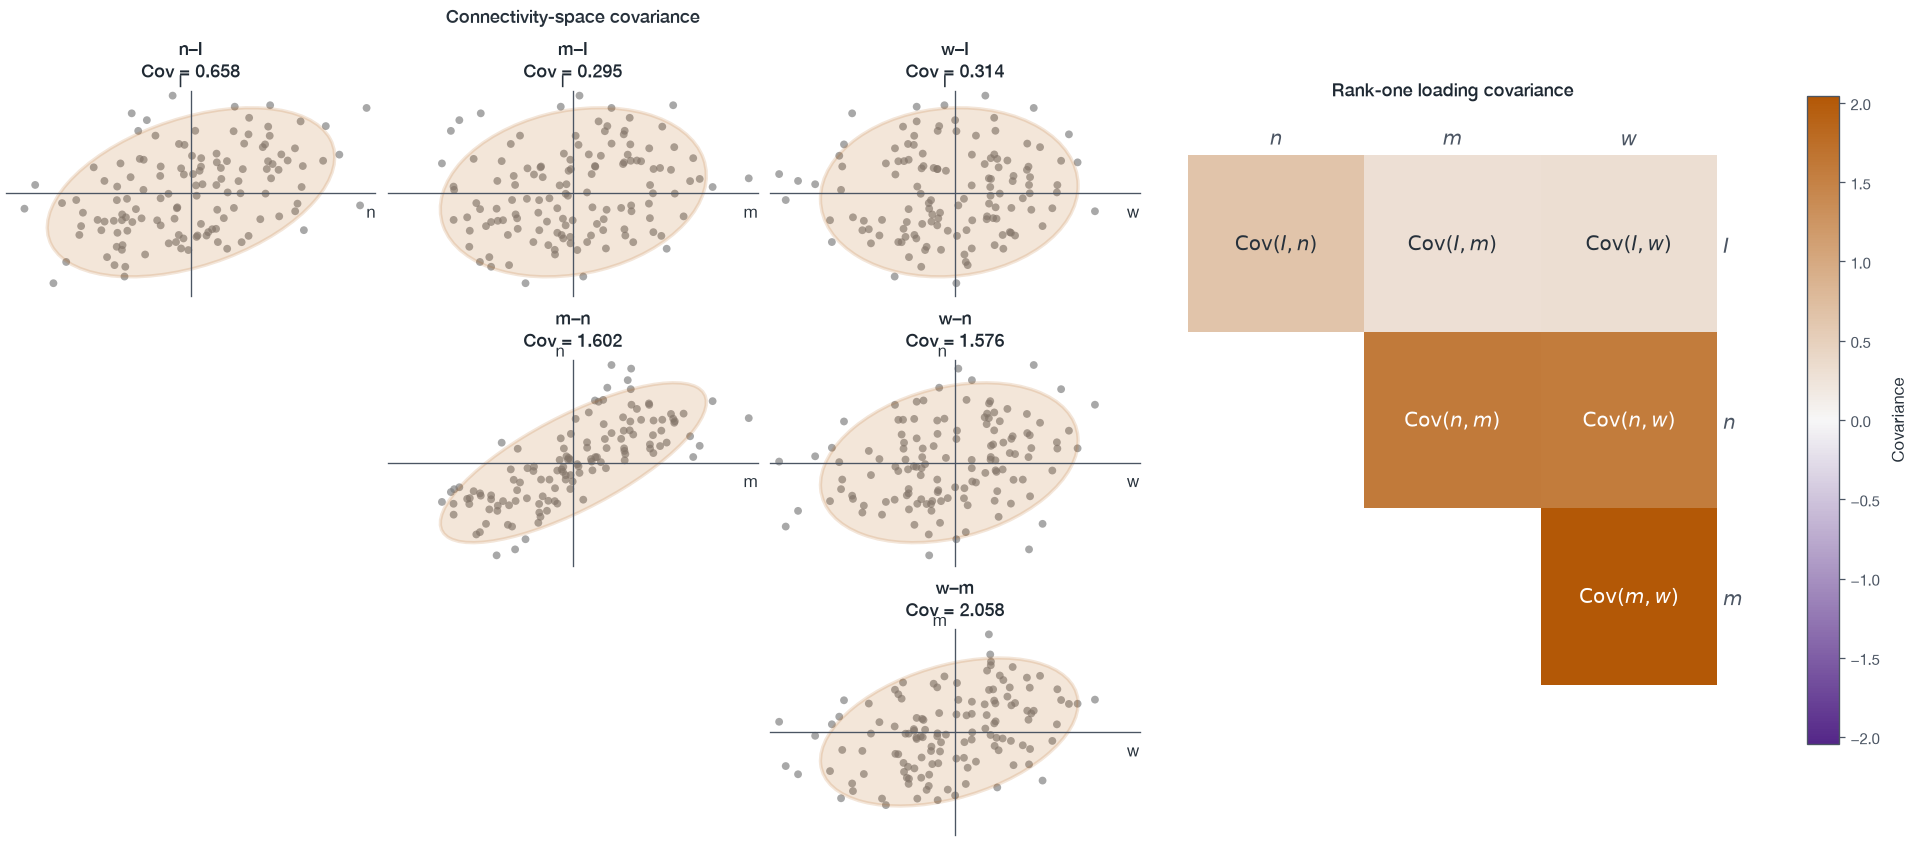

{'Cov(n, I)': 0.6531196302377552,
 'Cov(m, n)': 1.58964165924347,
 'Cov(m, w)': 2.042173281209281}

In [5]:
rank1_vectors = analysis.connectivity_vectors(rank1_model)
rank1_names = tuple(rank1_vectors)
rank1_loading_mean, rank1_loading_covariance = analysis.fit_loading_gaussian(
    rank1_vectors
)

rank1_loading_space_figure, _, _ = plotting.plot_connectivity_summary(
    rank1_vectors,
    rank1_names,
    rank1_loading_covariance,
    row_names=("I", "n", "m"),
    column_names=("n", "m", "w"),
    covariance_title="Rank-one loading covariance",
)
save_report_figure(
    rank1_loading_space_figure,
    "rank1-loading-space-covariance.pdf",
)
plt.show()

rank1_couplings = analysis.named_covariances(
    rank1_names,
    rank1_loading_covariance,
    (("n", "I"), ("m", "n"), ("m", "w")),
)
rank1_couplings


### 1.4 Is a four-dimensional Gaussian sufficient?

We fit one multivariate Gaussian to the 128 neuron rows, redraw complete
networks from that distribution, and test them without further training.
Matching a covariance *in expectation* need not give identical finite-\(N\)
behavior, especially near a bifurcation. The three panels below follow the
argument from left to right: a Gaussian draw reproduces the loading
marginals, preserves the covariance structure, and yields sampled networks
that retain the trained network's decision accuracy.

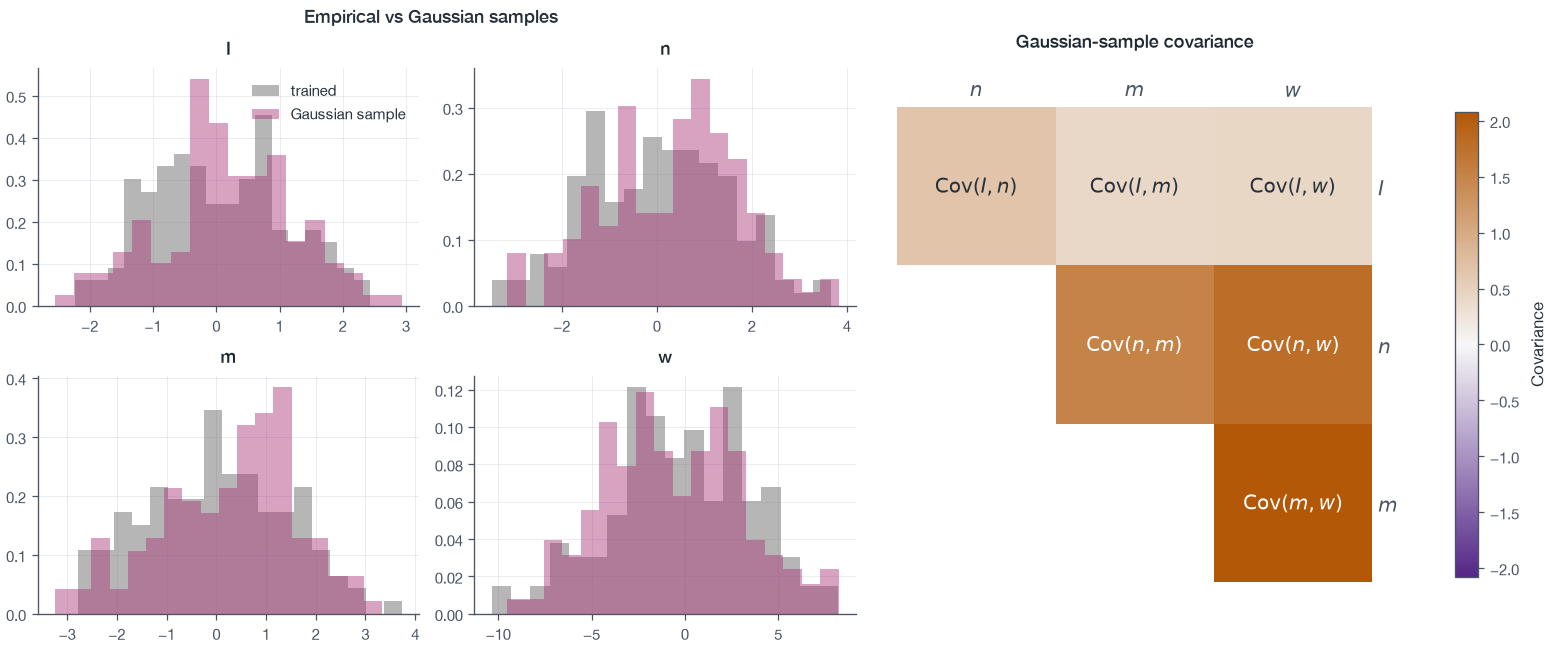

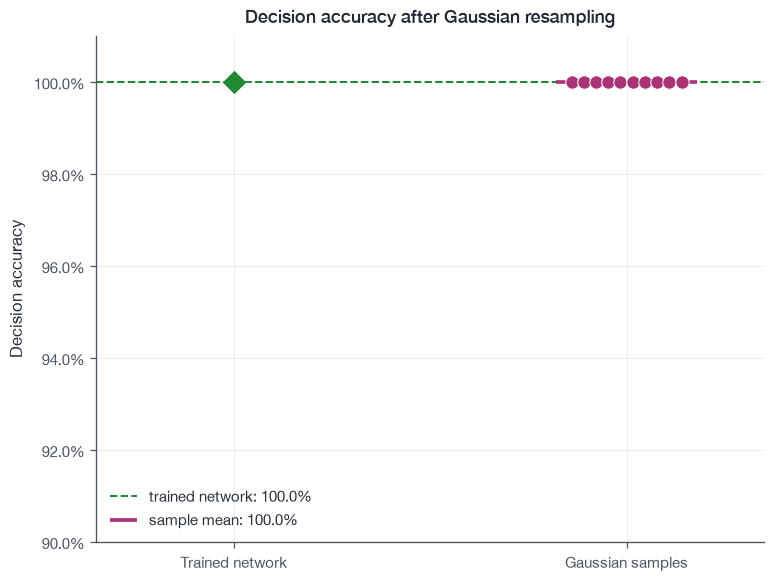

One-sample relative covariance error: 4.2%
Gaussian-network accuracy, mean [range]: 100.0% [100.0%, 100.0%]


In [6]:
rank1_sampled_vectors, rank1_sampled_covariance = (
    analysis.sample_loading_vectors(
        rank1_names,
        rank1_loading_mean,
        rank1_loading_covariance,
        num_samples=NUM_UNITS,
        rng=np.random.default_rng(BASE_SEED + 10),
    )
)
rank1_sampled_networks = analysis.sample_low_rank_rnns(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    num_networks=10,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 11),
)
rank1_sampled_accuracies = np.array(
    [
        decision_accuracy(
            network,
            torch.as_tensor(rank1_test_inputs, dtype=torch.float32),
            torch.as_tensor(rank1_test_labels),
            decision_steps=RANK1_DECISION_STEPS,
        )
        for network in rank1_sampled_networks
    ]
)
rank1_covariance_error = np.linalg.norm(
    rank1_sampled_covariance - rank1_loading_covariance
) / np.linalg.norm(rank1_loading_covariance)

plotting.plot_gaussian_sampling_summary(
    rank1_vectors,
    rank1_sampled_vectors,
    rank1_names,
    rank1_sampled_covariance,
    rank1_accuracy,
    rank1_sampled_accuracies,
    covariance_title="Gaussian-sample covariance",
)
plt.show()

print(f"One-sample relative covariance error: {rank1_covariance_error:.1%}")
print(
    "Gaussian-network accuracy, mean [range]: "
    f"{rank1_sampled_accuracies.mean():.1%} "
    f"[{rank1_sampled_accuracies.min():.1%}, {rank1_sampled_accuracies.max():.1%}]"
)


### 1.5 The population activity is two-dimensional

Starting from \(x(0)=0\), every drive lies in
\(\operatorname{span}\{m,I\}\): recurrence points along \(m\), input points
along \(I\), and leak cannot create a new direction. The trajectories should
therefore move with the stimulus and then separate by choice.

If \(m\) and \(I\) were unknown—as in a generic RNN or neural recording—we
would stack the centered states into a matrix \(X\), form the neuron-by-neuron
covariance \(C=X^\top X/(T-1)\), and diagonalize \(C\). Its eigenvectors are
the principal-component directions and each eigenvalue is the variance along
that direction.

The left panel below asks how many directions are needed. The right panel
projects every selected trial onto the first two covariance eigenvectors.
Repeated paths across trials show that this one PCA plane consistently captures
the population trajectories. PCA may rotate the axes within the plane, so PC1
and PC2 need not equal \(m\) and \(I\) individually. Here the model already tells
us that all states lie in \(\operatorname{span}\{m,I\}\); because the trials explore
two independent directions and PCA finds only two nonzero directions, its plane
is that same subspace. For noisy experimental data, factor analysis can separate
shared low-dimensional activity from neuron-specific noise.

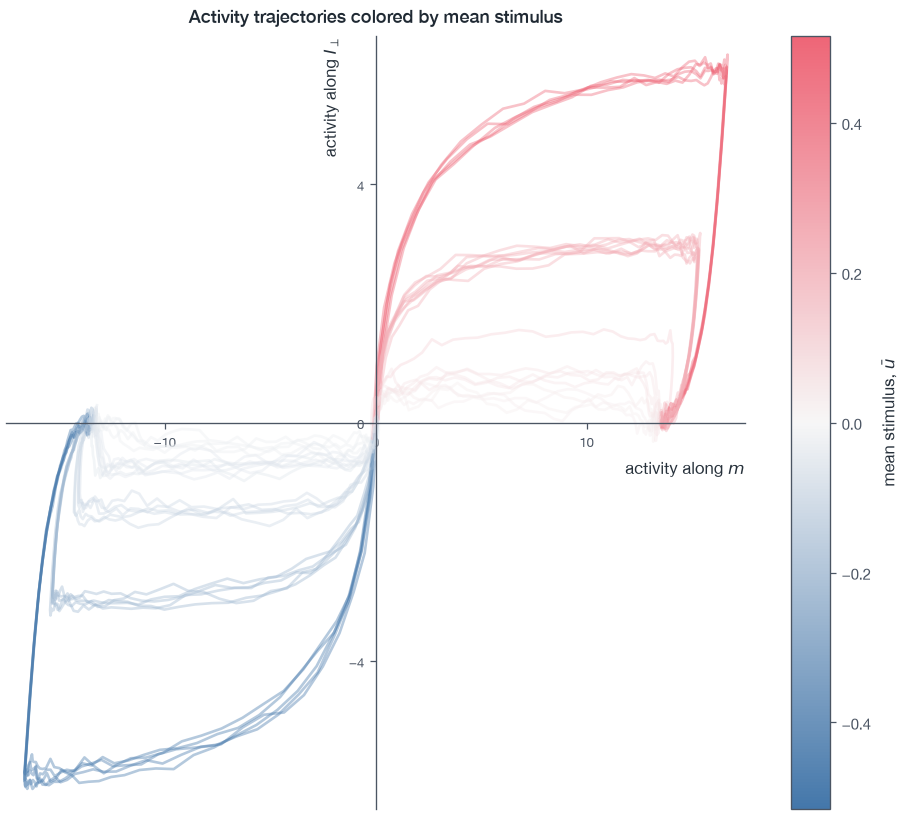

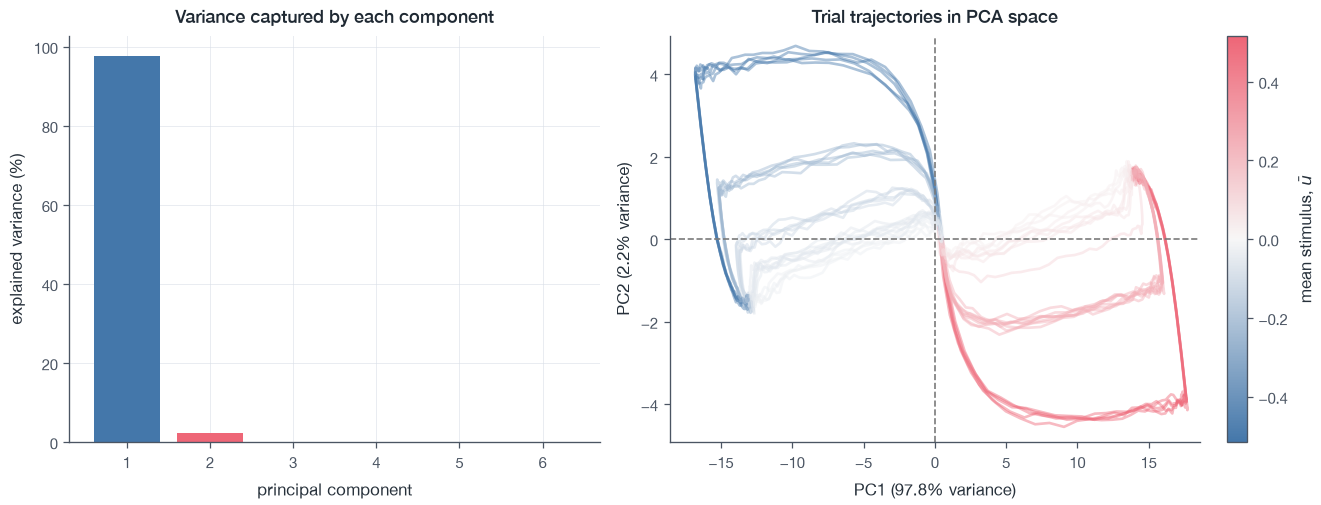

Variance explained by the first two PCs: 100.00%


In [7]:
rank1_projected = analysis.project_rank_one_activity(
    torch.as_tensor(rank1_states, dtype=torch.float32),
    rank1_model,
)
trajectory_subset = np.linspace(0, len(rank1_projected) - 1, 48, dtype=int)
rank1_latent_trajectories_figure, _ = (
    plotting.plot_activity_trajectories_by_stimulus(
        rank1_projected[trajectory_subset],
        stimulus_estimates[trajectory_subset],
    )
)
save_report_figure(
    rank1_latent_trajectories_figure,
    "rank1-latent-trajectories.pdf",
)
plt.show()

(
    rank1_explained_variance,
    rank1_pca_components,
    rank1_pca_trajectories,
) = analysis.principal_component_analysis(rank1_states)
rank1_pca_summary_figure, _ = plotting.plot_pca_summary(
    rank1_explained_variance,
    rank1_pca_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
save_report_figure(
    rank1_pca_summary_figure,
    "rank1-pca-summary.pdf",
)
plt.show()
print(
    "Variance explained by the first two PCs: "
    f"{rank1_explained_variance[:2].sum():.2%}"
)


### 1.6 A rank-generic Gaussian equivalent circuit

For jointly Gaussian loadings and
\(x_i\approx I_i v+\sum_r m_{ir}\kappa_r\), Stein's lemma gives

\[
\dot\kappa
=-\kappa+\mu_n\langle\tanh h\rangle
+\operatorname{Cov}(n,h)\langle\operatorname{sech}^2h\rangle,
\qquad
\dot v=-v+u,
\]

with the analogous expression for \(z\) using \(w\). For zero means and
orthogonal rank-one loadings this reduces to the handout:

\[
\dot\kappa=-\kappa+g(\Delta)
[\sigma_{mn}\kappa+\sigma_{nI}v],
\quad
\Delta^2=\sigma_m^2\kappa^2+\sigma_I^2v^2.
\]

Because the empirical circuit succeeds, we do not substitute the paper values.
If that fallback were needed, the handout leaves \(\sigma_m\) unspecified;
we would state the extra convention \(\sigma_m=1\) rather than guess silently.

The library implementation keeps the full fitted means and covariance, and
works unchanged for rank two.

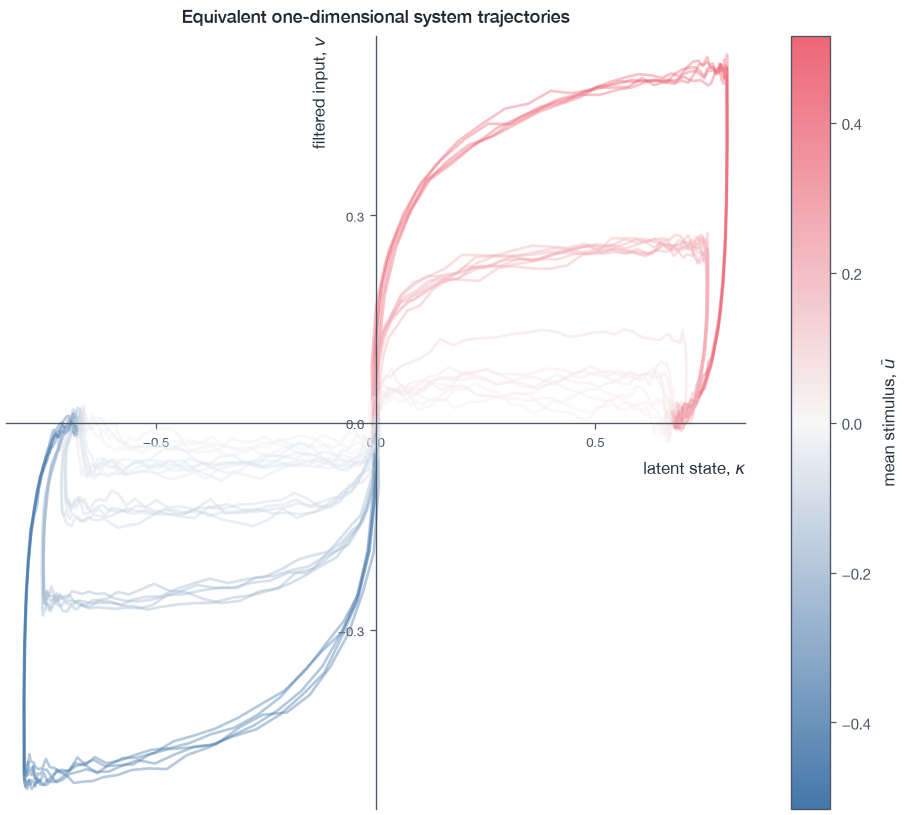

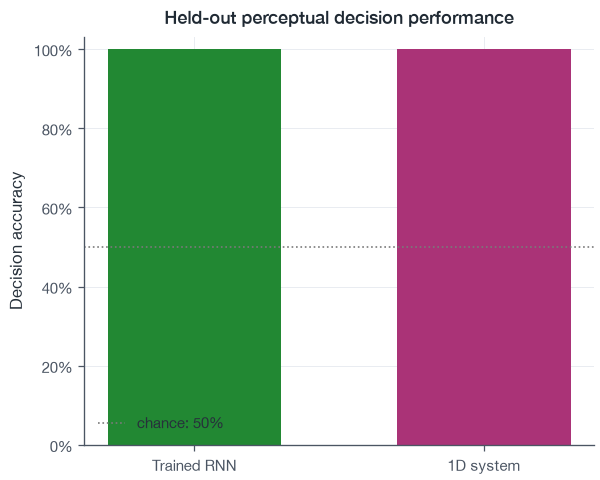

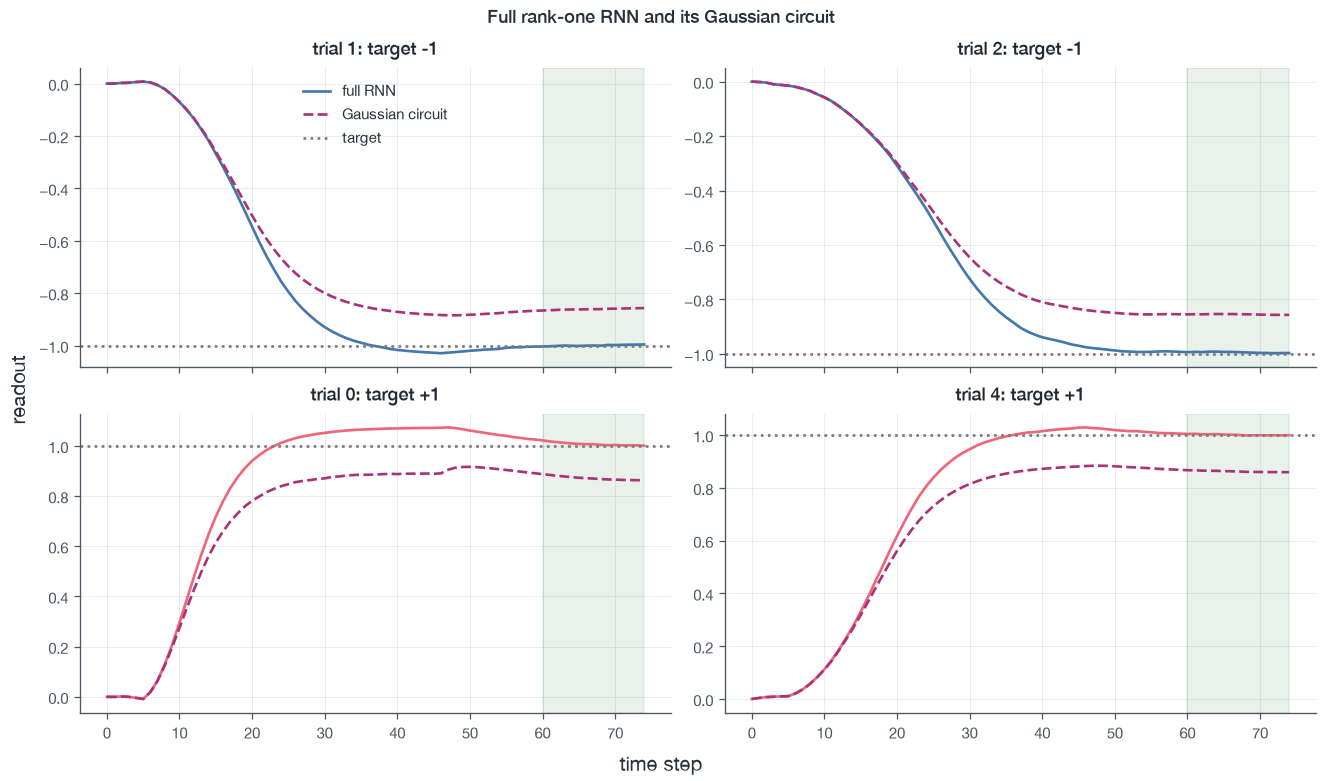

Gaussian-circuit sign accuracy: 100.0%


In [8]:
(
    rank1_reduced_outputs,
    rank1_reduced_kappa,
    rank1_filtered_input,
) = mean_field.simulate_gaussian_circuit(
    rank1_test_inputs,
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    step_size=rank1_model.step_size,
)
rank1_reduced_decisions = analysis.decision_values(
    rank1_reduced_outputs,
    RANK1_DECISION_STEPS,
)
rank1_reduced_accuracy = float(
    np.mean(
        np.where(rank1_reduced_decisions >= 0, 1, -1)
        == rank1_test_labels
    )
)

reduced_trajectories = np.dstack(
    (rank1_reduced_kappa[..., 0], rank1_filtered_input)
)
plotting.plot_reduced_system_trajectories(
    reduced_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
plt.show()
plotting.plot_reduced_system_accuracy(
    rank1_accuracy,
    rank1_reduced_accuracy,
)
plt.show()
plotting.plot_output_comparison(
    rank1_outputs,
    rank1_reduced_outputs,
    rank1_test_labels,
    rank1_examples,
    decision_steps=RANK1_DECISION_STEPS,
)
plt.show()

print(f"Gaussian-circuit sign accuracy: {rank1_reduced_accuracy:.1%}")


### 1.7 Fixed points reveal a categorical memory

At zero input, define the one-dimensional flow \(f(\kappa)=\dot\kappa\)
and energy \(q(\kappa)=f(\kappa)^2/2\). We minimize \(q\) from every local
basin on a dense grid, verify \(f\approx0\), and classify each root by the
slope \(f'(\kappa)\): negative is stable, positive is unstable.

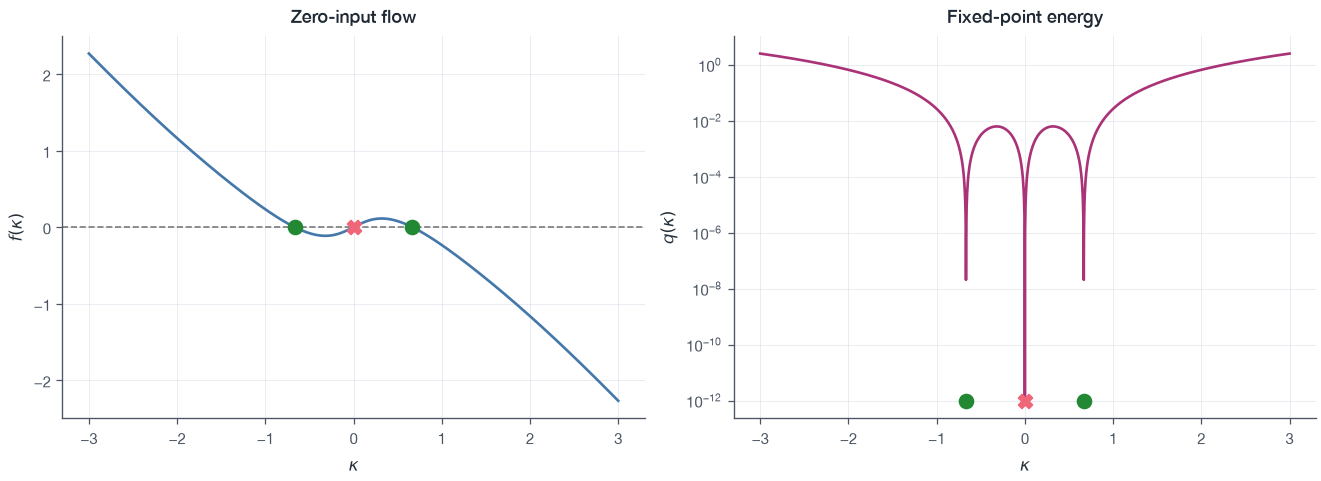

kappa=-0.6671  slope=-0.572  stable
kappa=-0.0000  slope=+0.590  unstable
kappa=+0.6671  slope=-0.572  stable


In [9]:
(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
) = mean_field.rank_one_fixed_points(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)
fixed_point_stability = np.where(
    fixed_point_slopes < 0,
    "stable",
    "unstable",
)
fixed_point_residuals = mean_field.gaussian_latent_flow(
    fixed_points[:, None],
    np.zeros(len(fixed_points)),
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)[:, 0]

plotting.plot_fixed_points(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
)
plt.show()

for point, slope, stability in zip(
    fixed_points,
    fixed_point_slopes,
    fixed_point_stability,
):
    print(f"kappa={point:+.4f}  slope={slope:+.3f}  {stability}")


A sign decision is naturally stored by two stable choice states separated by
an unstable boundary. An exact-value integrator would be qualitatively
different: it needs a continuum of marginal fixed points—a line attractor
with \(f(\kappa)\approx0\) across a range—so every input magnitude, not only
its sign, can persist.

## 2. Rank-two working memory: two trained solutions

Both networks learn the comparison target

\[
y=\frac{f_1-f_2}{24}.
\]

They answer different mechanistic questions:

- **Network A — fixed delay, random initialization.** Can an ordinary
  rank-two RNN solve the literal assignment task, and are its fitted
  covariances sufficient to reconstruct that solution?
- **Network B — randomized delays, paper-informed initialization.** If
  the fixed clock is removed and the paper's loading relations initialize
  the weights, does training produce persistent/transient dynamics, and
  do that network's *post-training* covariances reconstruct the result?

For either fitted network \(X\in\{A,B\}\), the handout circuit
implemented below is

\[
\begin{aligned}
\Delta_X^2
&=\sigma^X_{m_1m_1}\kappa_1^2
 +\sigma^X_{m_2m_2}\kappa_2^2
 +\sigma^X_{II}v^2,\\
\dot{\kappa}_r
&=-\kappa_r+
g(\Delta_X)\left(
\sigma^X_{n_rm_r}\kappa_r+\sigma^X_{n_rI}v
\right),\\
z_X
&=g(\Delta_X)\left(
\sigma^X_{wm_1}\kappa_1+\sigma^X_{wm_2}\kappa_2
\right),
\qquad
g(\Delta)=\mathbb{E}_{Z\sim\mathcal N(0,1)}
\left[\operatorname{sech}^2(\Delta Z)\right].
\end{aligned}
\]

The filtered stimulus obeys \(\dot v=-v+u(t)\). Superscript \(X\)
matters: A and B supply different fitted covariance entries to the same
equations.

The same three post-training tests are run for each network:

- finite \(N=128\) RNNs sampled from its fitted six-dimensional Gaussian;
- the general infinite-population circuit using the complete fitted
  mean and covariance;
- the handout's stricter two-dimensional diagonal circuit, instantiated
  from only the selected entries of that network's fitted covariance.

The two behavioral scores are evaluated within their own protocols.
Cross-network conclusions therefore compare mechanisms and reduction
fidelity, not raw MSEs as though the tasks were identical.

### 2.1 Network A evaluation grid

Network A uses the handout's fixed windows: the first inclusive window
is \(5{:}10\), the second is \(60{:}70\), and the final five of 80 steps
are scored. Frequencies come from \(\{10,14,\ldots,34\}\) Hz, giving a
complete \(7\times7\) evaluation grid.

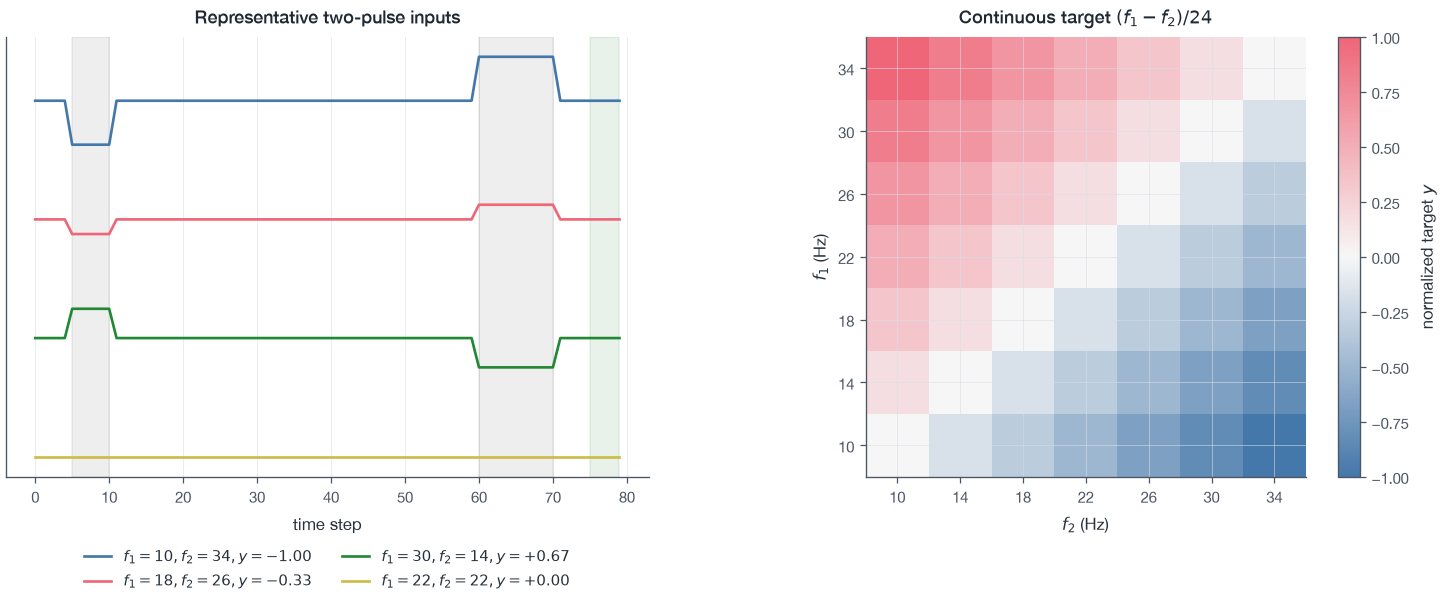

In [10]:
MEMORY_DECISION_STEPS = memory_task.FIXED_DECISION_STEPS
MEMORY_TRIAL_LENGTH = memory_task.FIXED_TRIAL_STEPS
memory_grid_pairs = memory_task.frequency_pair_grid()
memory_grid_inputs, memory_grid_targets = memory_task.make_fixed_delay_trials(
    memory_grid_pairs
)
target_matrix = memory_grid_targets.reshape(
    len(memory_task.FREQUENCIES),
    len(memory_task.FREQUENCIES),
)

outside_stimuli = np.ones(MEMORY_TRIAL_LENGTH, dtype=bool)
for start, stop in (
    memory_task.FIXED_FIRST_WINDOW,
    memory_task.FIXED_SECOND_WINDOW,
):
    outside_stimuli[start:stop] = False
assert memory_grid_inputs.shape == (49, MEMORY_TRIAL_LENGTH)
assert np.all(memory_grid_inputs[:, outside_stimuli] == 0)

example_pairs = np.array(((10, 34), (18, 26), (30, 14), (22, 22)))
example_inputs, example_targets = memory_task.make_fixed_delay_trials(
    example_pairs
)
plotting.plot_memory_trials(
    example_pairs,
    example_inputs,
    example_targets,
    target_matrix,
    memory_task.FREQUENCIES,
    first_window=memory_task.FIXED_FIRST_WINDOW,
    second_window=memory_task.FIXED_SECOND_WINDOW,
    decision_steps=MEMORY_DECISION_STEPS,
)
plt.show()


### 2.2 Network A — a fixed-delay oscillatory solution

#### 2.2.1 Train and verify the task

We train a rank-two RNN from random initialization and a matched rank-one
control. The full \(7\times7\) grid is scored after training, with
condition-balanced MSE required to be below \(5\times10^{-3}\).

In [11]:
MEMORY_TRAIN_TRIALS = 200
MEMORY_RANK2_EPOCHS = 600
MEMORY_RANK1_EPOCHS = 300

(
    memory_train_pairs,
    memory_train_inputs,
    memory_train_targets,
) = memory_task.sample_fixed_delay_trials(
    MEMORY_TRAIN_TRIALS,
    rng=np.random.default_rng(BASE_SEED),
)

torch.manual_seed(BASE_SEED)
oscillatory_model = LowRankRNN(NUM_UNITS, rank=2)
oscillatory_losses = train_model(
    oscillatory_model,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK2_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=200,
)

torch.manual_seed(BASE_SEED + 1)
fixed_rank1_control = LowRankRNN(NUM_UNITS, rank=1)
fixed_rank1_losses = train_model(
    fixed_rank1_control,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=None,
)

oscillatory_grid_outputs, oscillatory_grid_states = analysis.run_model(
    oscillatory_model,
    memory_grid_inputs,
)
oscillatory_grid_decisions = analysis.decision_values(
    oscillatory_grid_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_mse, oscillatory_r2 = analysis.regression_metrics(
    oscillatory_grid_decisions,
    memory_grid_targets,
)

fixed_rank1_outputs, _ = analysis.run_model(
    fixed_rank1_control,
    memory_grid_inputs,
)
fixed_rank1_decisions = analysis.decision_values(
    fixed_rank1_outputs,
    MEMORY_DECISION_STEPS,
)
fixed_rank1_mse, fixed_rank1_r2 = analysis.regression_metrics(
    fixed_rank1_decisions,
    memory_grid_targets,
)

assert oscillatory_mse < TASK_MSE_THRESHOLD
print(f"Network A rank-two MSE: {oscillatory_mse:.6f}")
print(f"Network A rank-two R²:  {oscillatory_r2:.4f}")
print(f"Matched rank-one MSE:    {fixed_rank1_mse:.6f}")


Epoch 200: loss=0.115002


Epoch 400: loss=0.004609


Epoch 600: loss=0.000548


Network A rank-two MSE: 0.000788
Network A rank-two R²:  0.9965
Matched rank-one MSE:    0.112504


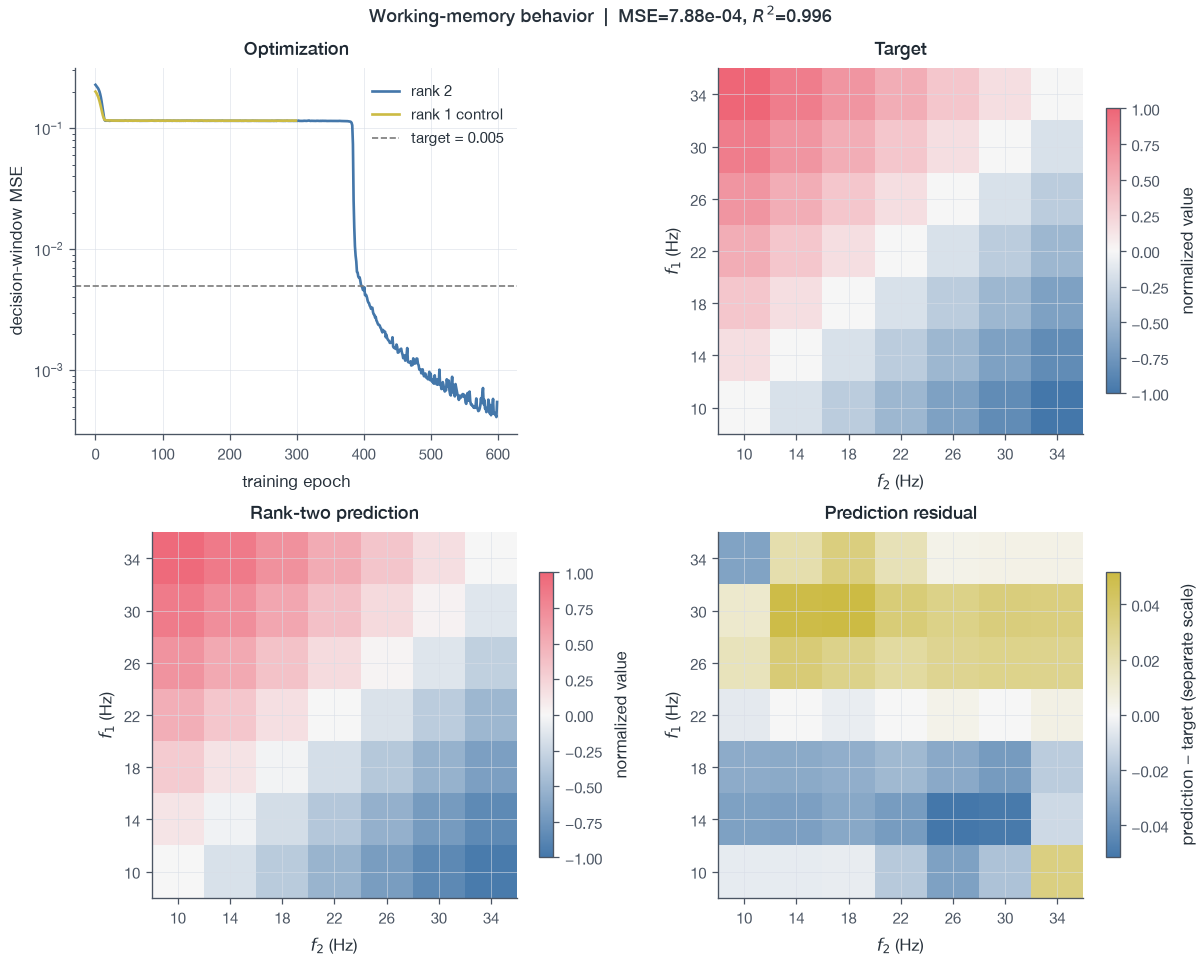

In [12]:
plotting.plot_memory_behavior(
    oscillatory_losses,
    fixed_rank1_losses,
    target_matrix,
    oscillatory_grid_decisions,
    memory_task.FREQUENCIES,
    mse=oscillatory_mse,
    r_squared=oscillatory_r2,
    loss_threshold=TASK_MSE_THRESHOLD,
)
plt.show()


#### 2.2.2 Identify the dynamics: a coupled rotation

Raw rank-two factors have the gauge freedom
\(M\to MA,\ N\to NA^{-\top}\). We first place Network A in the
repository's SVD basis, which exactly preserves \(MN^\top\). We then
project activity onto its two recurrent coordinates and inspect the
recurrent-overlap and local-flow eigenvalues.

In [13]:
oscillatory_canonical, oscillatory_reconstruction_error = (
    analysis.svd_canonical_model(oscillatory_model)
)
oscillatory_m = oscillatory_canonical.m.detach().numpy()
oscillatory_n = oscillatory_canonical.n.detach().numpy()
oscillatory_overlap = analysis.connectivity_overlap(
    oscillatory_m,
    oscillatory_n,
)
oscillatory_overlap_eigenvalues = np.linalg.eigvals(
    oscillatory_overlap
)

print(
    "Connectivity reconstruction error: "
    f"{oscillatory_reconstruction_error:.2e}"
)
print("Recurrent overlap nᵀm/N:\n", np.round(oscillatory_overlap, 3))
print(
    "Small-signal overlap eigenvalues:",
    np.round(oscillatory_overlap_eigenvalues, 3),
)


Connectivity reconstruction error: 3.13e-08
Recurrent overlap nᵀm/N:
 [[ 1.234 -0.557]
 [ 0.197  0.743]]
Small-signal overlap eigenvalues: [0.989+0.223j 0.989-0.223j]


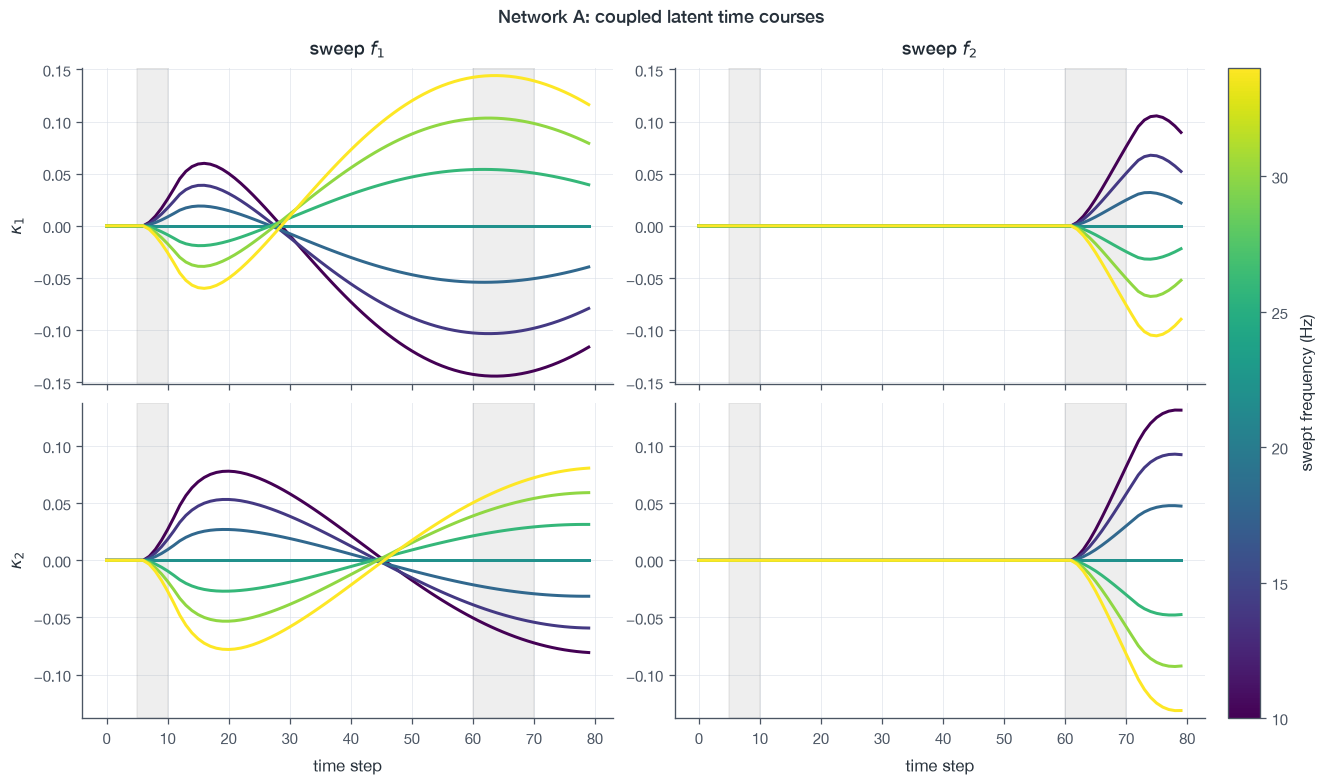

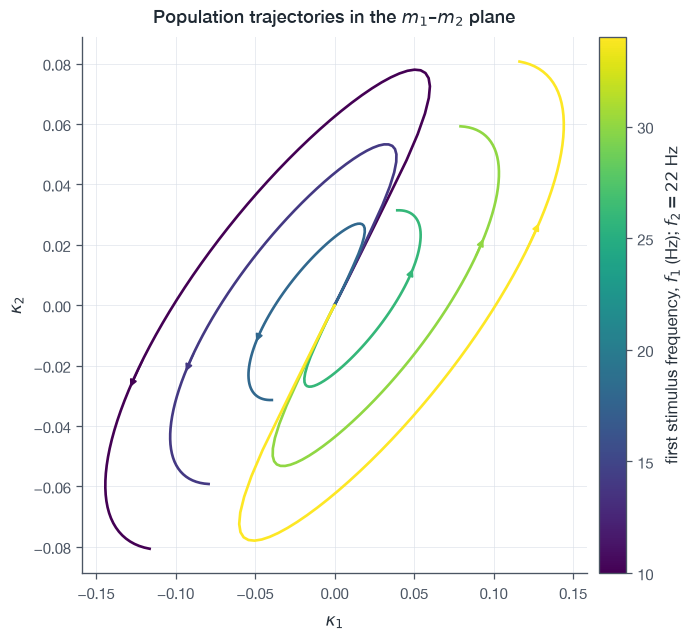

Median delay-flow eigenvalues (1/tau): [-0.021 -0.021]


In [14]:
first_sweep_pairs, second_sweep_pairs = memory_task.frequency_sweeps()
first_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    first_sweep_pairs
)
second_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    second_sweep_pairs
)
oscillatory_basis = np.column_stack(
    (oscillatory_m, oscillatory_canonical.I.detach().numpy())
)
(
    first_sweep_outputs,
    first_sweep_states,
    first_sweep_coordinates,
) = analysis.simulate_and_project(
    oscillatory_canonical,
    first_sweep_inputs,
    oscillatory_basis,
)
(
    second_sweep_outputs,
    second_sweep_states,
    second_sweep_coordinates,
) = analysis.simulate_and_project(
    oscillatory_canonical,
    second_sweep_inputs,
    oscillatory_basis,
)

plotting.plot_latent_sweeps(
    first_sweep_coordinates[..., :2],
    second_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    time_values=np.arange(MEMORY_TRIAL_LENGTH),
    window_spans=(
        (
            memory_task.FIXED_FIRST_WINDOW[0],
            memory_task.FIXED_FIRST_WINDOW[1] - 1,
        ),
        (
            memory_task.FIXED_SECOND_WINDOW[0],
            memory_task.FIXED_SECOND_WINDOW[1] - 1,
        ),
    ),
    column_titles=(r"sweep $f_1$", r"sweep $f_2$"),
    row_labels=(r"$\kappa_1$", r"$\kappa_2$"),
    title="Network A: coupled latent time courses",
)
plt.show()
plotting.plot_latent_plane(
    first_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    colorbar_label=r"first stimulus frequency, $f_1$ (Hz); $f_2=22$ Hz",
)
plt.show()

delay_probe_states = first_sweep_states[
    :, memory_task.FIXED_SECOND_WINDOW[0] - 1
]
delay_jacobian_eigenvalues = analysis.latent_jacobian_eigenvalues(
    oscillatory_canonical,
    delay_probe_states,
)
median_delay_eigenvalues = np.median(
    np.sort(delay_jacobian_eigenvalues.real, axis=1),
    axis=0,
)[::-1]
print(
    "Median delay-flow eigenvalues (1/tau):",
    np.round(median_delay_eigenvalues, 3),
)


The overlap eigenvalues form a complex conjugate pair, and both local
delay-flow eigenvalues are slow. Together with the curved phase portrait,
this identifies a coupled, slowly decaying rotation. Network A uses the
known fixed delay as a clock; it does **not** implement separately
readable persistent and transient modes.

#### 2.2.3 Fit Network A's post-training loading Gaussian

Only now—after fixing the basis and identifying the mechanism—do we fit
the six-dimensional Gaussian over
\((I,n_1,n_2,m_1,m_2,w)\). The variables named
`oscillatory_loading_mean` and `oscillatory_loading_covariance` are the
sole source for all three tests that follow: finite Gaussian RNNs, the
full-covariance circuit, and the handout diagonal circuit.

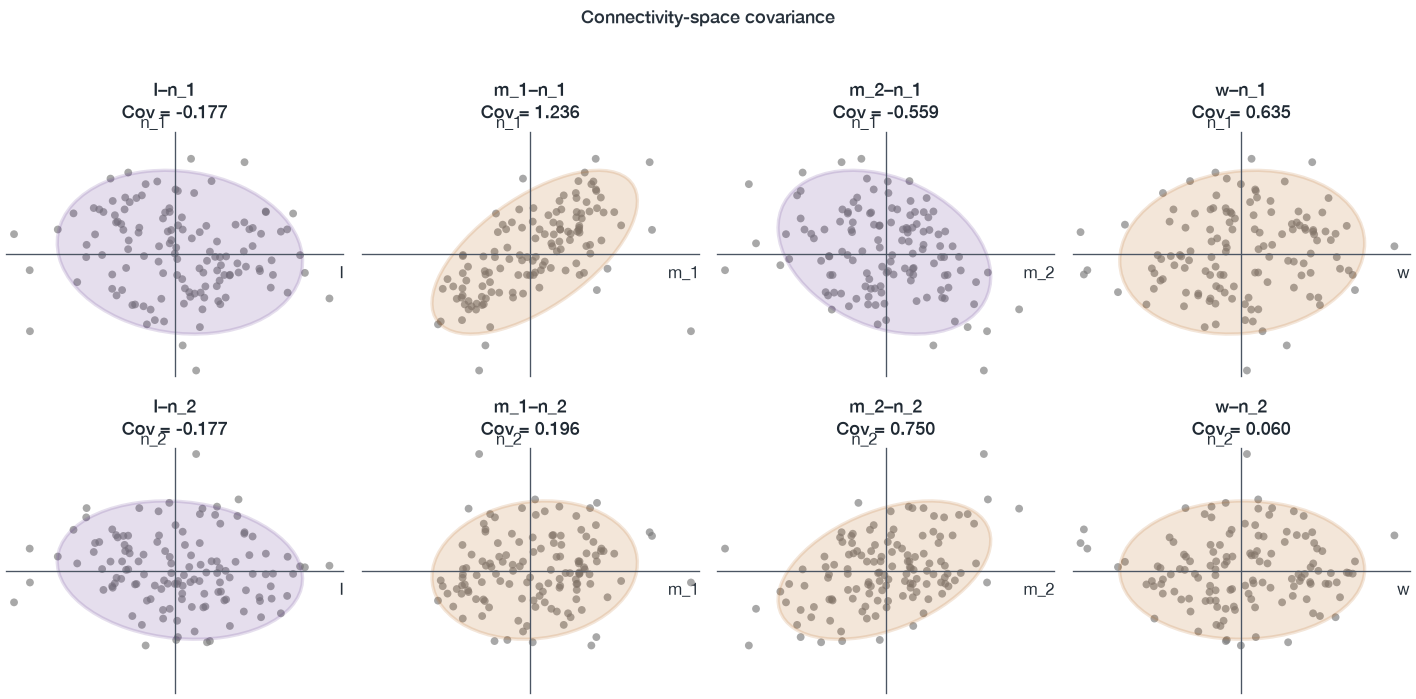

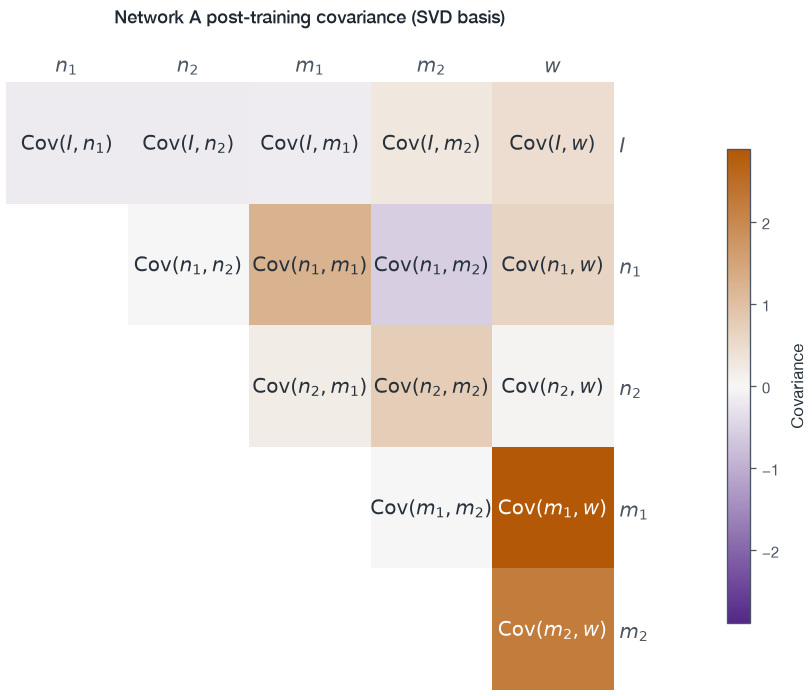

In [15]:
oscillatory_vectors = analysis.connectivity_vectors(
    oscillatory_canonical
)
oscillatory_names = tuple(oscillatory_vectors)
(
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
) = analysis.fit_loading_gaussian(oscillatory_vectors)

plotting.plot_connectivity_pairs(
    oscillatory_vectors,
    row_names=("n_1", "n_2"),
    column_names=("I", "m_1", "m_2", "w"),
)
plt.show()
plotting.plot_connectivity_covariance(
    oscillatory_names,
    oscillatory_loading_covariance,
    title="Network A post-training covariance (SVD basis)",
)
plt.show()


#### 2.2.4 Reconstruct Network A three ways

All three reconstructions start from **Network A's SVD-basis
post-training Gaussian fit** and are tested on the same full fixed-delay
grid:

1. ten complete finite \(N=128\) Gaussian-sampled RNNs;
2. one infinite-population circuit using the complete fitted mean and
   covariance;
3. one handout-style diagonal circuit retaining only
   \(\operatorname{Cov}(n_r,m_r)\), \(\operatorname{Cov}(n_r,I)\),
   \(\operatorname{Cov}(w,m_r)\), and the diagonal variances that set
   \(\Delta\).

The third test deliberately discards fitted means, cross-mode recurrent
couplings, and all basis cross-covariances. For Network A's rotating
SVD-basis solution, that is a substantive mechanistic ablation. No paper
coefficient and no statistic from Network B enters this section.

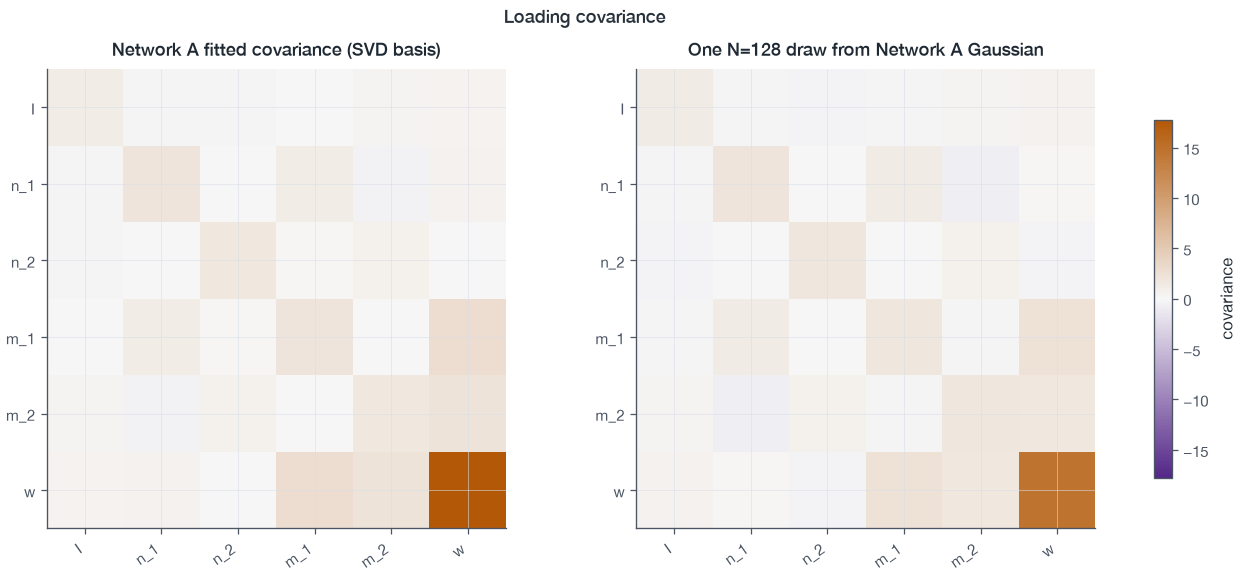

Network A Gaussian-sampled MSE, median [range]: 0.5013 [0.0882, 3.2224]
Samples with complex overlap modes: 40%


In [16]:
(
    oscillatory_sampled_vectors,
    oscillatory_sampled_covariance,
) = analysis.sample_loading_vectors(
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    num_samples=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 20),
)
plotting.plot_covariance_comparison(
    oscillatory_names,
    oscillatory_loading_covariance,
    oscillatory_sampled_covariance,
    titles=(
        "Network A fitted covariance (SVD basis)",
        "One N=128 draw from Network A Gaussian",
    ),
)
plt.show()

oscillatory_sampled_networks = analysis.sample_low_rank_rnns(
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 21),
)
oscillatory_sampled_mses = analysis.network_regression_mses(
    oscillatory_sampled_networks,
    memory_grid_inputs,
    memory_grid_targets,
    decision_steps=MEMORY_DECISION_STEPS,
)
oscillatory_sampled_overlap_eigenvalues = np.array(
    [
        np.linalg.eigvals(
            analysis.connectivity_overlap(
                network.m.detach().numpy(),
                network.n.detach().numpy(),
            )
        )
        for network in oscillatory_sampled_networks
    ]
)
oscillatory_sampled_complex_fraction = np.mean(
    np.any(
        np.abs(oscillatory_sampled_overlap_eigenvalues.imag) > 1e-6,
        axis=1,
    )
)

print(
    "Network A Gaussian-sampled MSE, median [range]: "
    f"{np.median(oscillatory_sampled_mses):.4f} "
    f"[{oscillatory_sampled_mses.min():.4f}, "
    f"{oscillatory_sampled_mses.max():.4f}]"
)
print(
    "Samples with complex overlap modes: "
    f"{oscillatory_sampled_complex_fraction:.0%}"
)


**Entries from Network A's fitted covariance retained by the handout circuit**

| Retained quantity | Fitted value |
|---|---:|
| `Cov(n_1, m_1)` | 1.2264 |
| `Cov(n_2, m_2)` | 0.7441 |
| `Cov(n_1, I)` | -0.1752 |
| `Cov(n_2, I)` | -0.1753 |
| `Cov(w, m_1)` | 2.8863 |
| `Cov(w, m_2)` | 2.2146 |
| `Cov(m_1, m_1)` | 1.9645 |
| `Cov(m_2, m_2)` | 1.7323 |
| `Cov(I, I)` | 1.1766 |

| Network A system | MSE | R² | MSE < 0.005? |
|---|---:|---:|:---:|
| Source trained RNN | 0.000788 | 0.9965 | yes |
| Full-covariance Gaussian circuit | 0.018029 | 0.9189 | no |
| Handout diagonal circuit | 0.984745 | -3.4314 | no |
| Finite Gaussian-sampled RNNs | median 0.5013 | — | 0/10 |

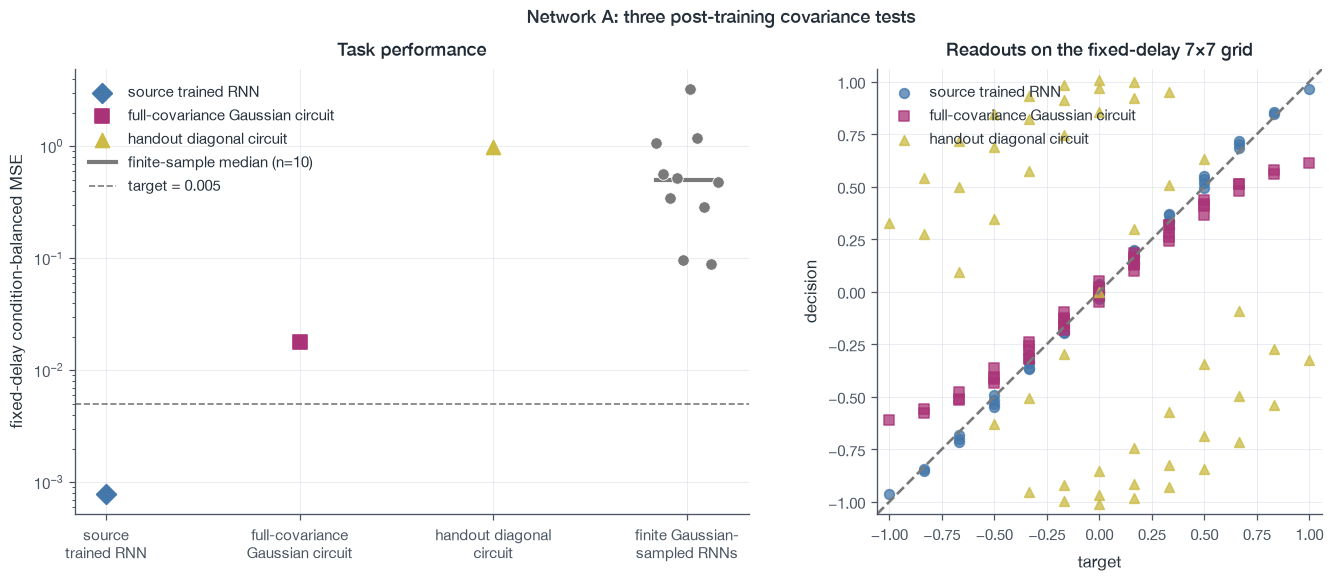

Network A source trained RNN MSE:       0.000788
Network A full-covariance circuit MSE: 0.018029
Network A handout diagonal circuit MSE: 0.984745
Network A Gaussian-sampled RNN MSE, median [range]: 0.5013 [0.0882, 3.2224]


In [17]:
(
    oscillatory_reduced_outputs,
    oscillatory_reduced_kappa,
    oscillatory_reduced_input,
) = mean_field.simulate_gaussian_circuit(
    memory_grid_inputs,
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)
oscillatory_reduced_decisions = analysis.decision_values(
    oscillatory_reduced_outputs,
    MEMORY_DECISION_STEPS,
)
(
    oscillatory_reduced_mse,
    oscillatory_reduced_r2,
) = analysis.regression_metrics(
    oscillatory_reduced_decisions,
    memory_grid_targets,
)

(
    oscillatory_diagonal_outputs,
    oscillatory_diagonal_kappa,
    oscillatory_diagonal_input,
) = mean_field.simulate_diagonal_circuit(
    memory_grid_inputs,
    oscillatory_names,
    oscillatory_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)
oscillatory_diagonal_decisions = analysis.decision_values(
    oscillatory_diagonal_outputs,
    MEMORY_DECISION_STEPS,
)
(
    oscillatory_diagonal_mse,
    oscillatory_diagonal_r2,
) = analysis.regression_metrics(
    oscillatory_diagonal_decisions,
    memory_grid_targets,
)

diagonal_covariance_pairs = (
    ("n_1", "m_1"),
    ("n_2", "m_2"),
    ("n_1", "I"),
    ("n_2", "I"),
    ("w", "m_1"),
    ("w", "m_2"),
    ("m_1", "m_1"),
    ("m_2", "m_2"),
    ("I", "I"),
)
oscillatory_diagonal_covariances = analysis.named_covariances(
    oscillatory_names,
    oscillatory_loading_covariance,
    diagonal_covariance_pairs,
)
oscillatory_covariance_rows = "\n".join(
    f"| `{quantity}` | {value:.4f} |"
    for quantity, value in oscillatory_diagonal_covariances.items()
)
display(
    Markdown(
        "**Entries from Network A's fitted covariance retained by the "
        "handout circuit**\n\n"
        "| Retained quantity | Fitted value |\n"
        "|---|---:|\n"
        + oscillatory_covariance_rows
    )
)

oscillatory_result_rows = (
    (
        "Source trained RNN",
        oscillatory_mse,
        oscillatory_r2,
        oscillatory_mse < TASK_MSE_THRESHOLD,
    ),
    (
        "Full-covariance Gaussian circuit",
        oscillatory_reduced_mse,
        oscillatory_reduced_r2,
        oscillatory_reduced_mse < TASK_MSE_THRESHOLD,
    ),
    (
        "Handout diagonal circuit",
        oscillatory_diagonal_mse,
        oscillatory_diagonal_r2,
        oscillatory_diagonal_mse < TASK_MSE_THRESHOLD,
    ),
)
oscillatory_result_table = "\n".join(
    f"| {system} | {mse:.6f} | {r_squared:.4f} | "
    f"{'yes' if passed else 'no'} |"
    for system, mse, r_squared, passed in oscillatory_result_rows
)
display(
    Markdown(
        "| Network A system | MSE | R² | MSE < 0.005? |\n"
        "|---|---:|---:|:---:|\n"
        + oscillatory_result_table
        + f"\n| Finite Gaussian-sampled RNNs | "
        f"median {np.median(oscillatory_sampled_mses):.4f} | — | "
        f"{np.sum(oscillatory_sampled_mses < TASK_MSE_THRESHOLD)}"
        f"/{NUM_GAUSSIAN_NETWORKS} |"
    )
)

plotting.plot_gaussian_pipeline(
    oscillatory_mse,
    oscillatory_reduced_mse,
    oscillatory_diagonal_mse,
    oscillatory_sampled_mses,
    memory_grid_targets,
    oscillatory_grid_decisions,
    oscillatory_reduced_decisions,
    oscillatory_diagonal_decisions,
    threshold=TASK_MSE_THRESHOLD,
    title="Network A: three post-training covariance tests",
    score_label="fixed-delay condition-balanced MSE",
    readout_title="Readouts on the fixed-delay 7×7 grid",
)
plt.show()

print(f"Network A source trained RNN MSE:       {oscillatory_mse:.6f}")
print(f"Network A full-covariance circuit MSE: {oscillatory_reduced_mse:.6f}")
print(f"Network A handout diagonal circuit MSE:{oscillatory_diagonal_mse: .6f}")
print(
    "Network A Gaussian-sampled RNN MSE, median [range]: "
    f"{np.median(oscillatory_sampled_mses):.4f} "
    f"[{oscillatory_sampled_mses.min():.4f}, "
    f"{oscillatory_sampled_mses.max():.4f}]"
)

Network A's four-way comparison separates two failure modes. Its source
RNN solves the task (MSE \(0.0008\)), but finite Gaussian RNNs do not
(median MSE \(0.5013\); \(0/10\) pass). The infinite-population
full-covariance circuit is much closer (MSE \(0.0180\), \(R^2=0.9189\))
but still misses the criterion.

The handout diagonal circuit fails decisively (MSE \(0.9847\),
\(R^2=-3.4314\)). This is mechanistically informative: Network A stores
the comparison in a coupled rotation, and the diagonal circuit deletes
the off-diagonal recurrent terms that generate that rotation. It is an
ablation of the handout assumptions, not another finite Gaussian draw.

### 2.3 Network B — a paper-informed persistent/transient solution

#### 2.3.1 Initialize, train, and verify delay-robust behavior

Network B starts from the handout's loading relations

\[
n_1=m_1+0.5I,\qquad
n_2=0.5m_2+1.9I,\qquad
w=2.8m_1-2.2m_2+\text{independent residual}.
\]

These coefficients initialize the weights; they are **not** substituted
later for the trained network's empirical covariance. We then train on
every integer frequency from 10 to 34 Hz and randomize the blank delay
with a 500–2000 ms curriculum. This removes the fixed-clock shortcut.

After training, both reduced circuits are re-instantiated from Network
B's own fitted covariance. Thus “paper-informed initialization” and
“post-training handout-style reduction” remain separate operations.

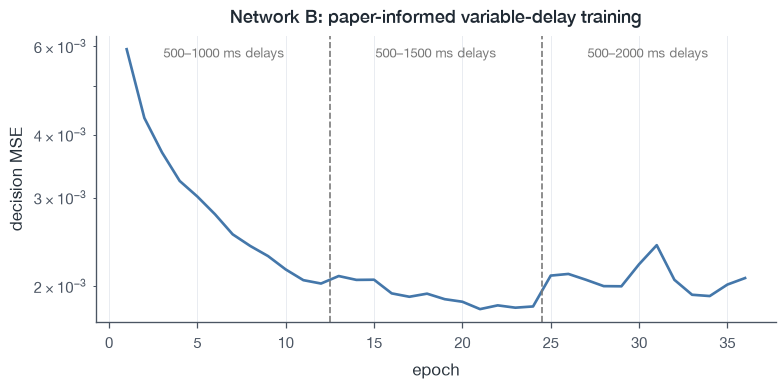

Final training MSE: 0.002075


In [18]:
PERSISTENT_TRANSIENT_SEED = 2032
PERSISTENT_TRANSIENT_EPOCHS = 12
DENSE_FREQUENCIES = np.arange(10, 35)
DELAY_CURRICULUM = (
    np.arange(25, 51),
    np.arange(25, 76),
    np.arange(25, 101),
)

persistent_model = persistent_transient_rnn(
    NUM_UNITS,
    seed=PERSISTENT_TRANSIENT_SEED,
)
persistent_losses = train_variable_delay(
    persistent_model,
    DELAY_CURRICULUM,
    rng=np.random.default_rng(PERSISTENT_TRANSIENT_SEED),
    frequencies=DENSE_FREQUENCIES,
    num_trials=640,
    epochs_per_stage=PERSISTENT_TRANSIENT_EPOCHS,
    batch_size=32,
    learning_rate=5e-3,
    max_gradient_norm=1.0,
)

plotting.plot_training_loss(
    persistent_losses,
    title="Network B: paper-informed variable-delay training",
    stage_ends=(12, 24),
    stage_labels=(
        "500–1000 ms delays",
        "500–1500 ms delays",
        "500–2000 ms delays",
    ),
)
plt.show()
print(f"Final training MSE: {persistent_losses[-1]:.4g}")


In [19]:
probe_delays = np.array((25, 50, 75, 100))
persistent_probe_mses = analysis.variable_delay_mses(
    persistent_model,
    memory_grid_pairs,
    probe_delays,
)

assert persistent_probe_mses.max() < TASK_MSE_THRESHOLD
print(
    "Network B MSE at 500, 1000, 1500, 2000 ms:",
    np.round(persistent_probe_mses, 4),
)


Network B MSE at 500, 1000, 1500, 2000 ms: [0.0026 0.0027 0.003  0.0034]


#### 2.3.2 Identify the dynamics: persistent and transient real modes

Network B has real recurrent-overlap modes, so we transform it into a
unit-RMS real-mode basis. The slow mode should retain the first stimulus;
the contracting mode should respond to the second and then decay.

In [20]:
persistent_m, persistent_n, persistent_overlap_values = (
    analysis.real_overlap_modes(persistent_model)
)
persistent_overlap = analysis.connectivity_overlap(
    persistent_m,
    persistent_n,
)
persistent_zero_state_flow = persistent_overlap_values - 1

local_probe_pairs = np.column_stack(
    (
        memory_task.FREQUENCIES,
        np.full(
            len(memory_task.FREQUENCIES),
            memory_task.FREQUENCY_CENTER,
        ),
    )
)
local_inputs, _, _ = memory_task.make_variable_delay_trials(
    local_probe_pairs,
    np.full(len(local_probe_pairs), 100),
)
_, local_states = analysis.run_model(
    persistent_model,
    local_inputs,
)
local_step = (
    memory_task.VARIABLE_FIXATION_STEPS
    + memory_task.VARIABLE_STIMULUS_STEPS
    + 100
    - 1
)
local_flow_values = analysis.latent_jacobian_eigenvalues(
    persistent_model,
    local_states[:, local_step],
    m=persistent_m,
    n=persistent_n,
)

print("Loop gains:", np.round(persistent_overlap_values, 3))
print(
    "Zero-state flow eigenvalues (1/tau):",
    np.round(persistent_zero_state_flow, 3),
)
print(
    "Late-delay flow ranges (1/tau):",
    [
        tuple(
            np.round(
                (
                    local_flow_values[:, mode].real.min(),
                    local_flow_values[:, mode].real.max(),
                ),
                3,
            )
        )
        for mode in range(2)
    ],
)


Loop gains: [ 1.011 -0.218]
Zero-state flow eigenvalues (1/tau): [ 0.011 -1.218]
Late-delay flow ranges (1/tau): [(np.float32(-0.028), np.float32(0.011)), (np.float32(-1.218), np.float32(-1.215))]


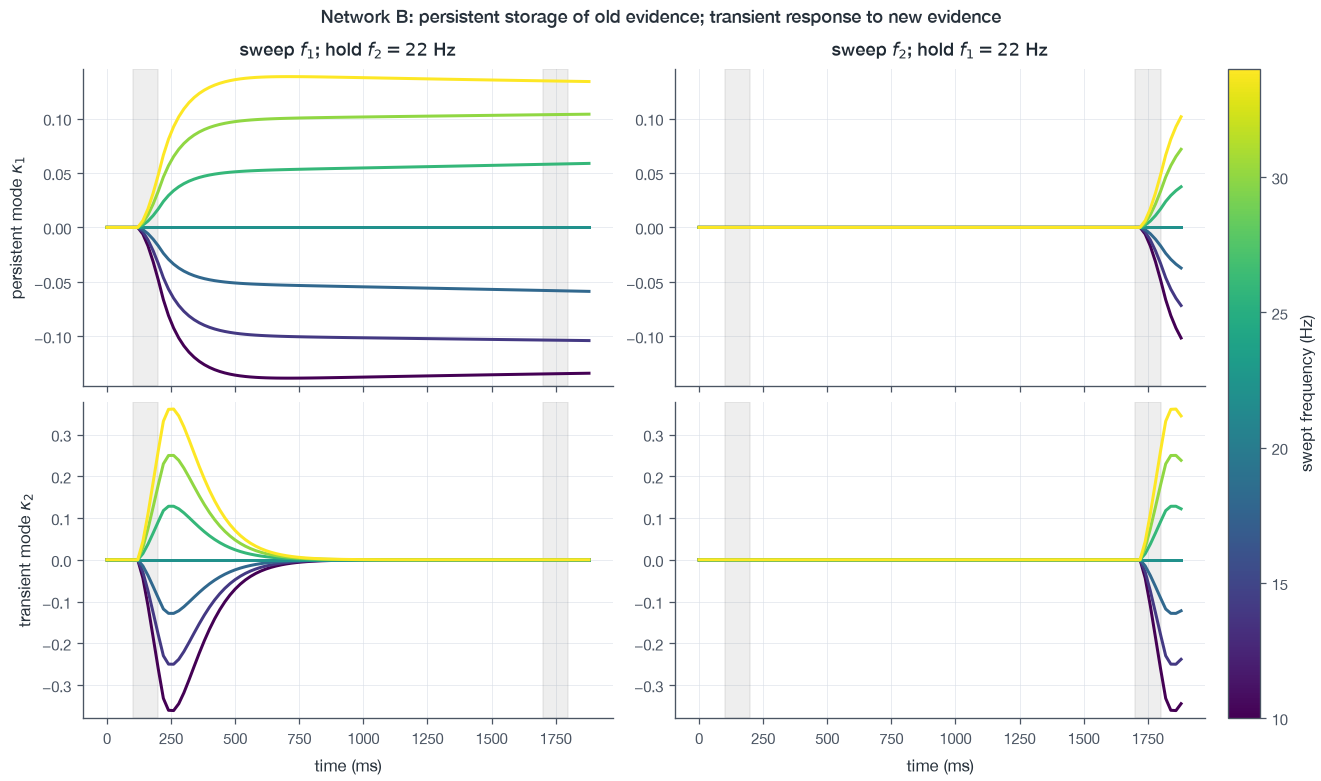

In [21]:
persistent_delay = 75
first_frequency_sweep, second_frequency_sweep = (
    memory_task.frequency_sweeps()
)
first_mode_inputs, _, _ = memory_task.make_variable_delay_trials(
    first_frequency_sweep,
    np.full(len(first_frequency_sweep), persistent_delay),
)
second_mode_inputs, _, _ = memory_task.make_variable_delay_trials(
    second_frequency_sweep,
    np.full(len(second_frequency_sweep), persistent_delay),
)
persistent_basis = np.column_stack(
    (persistent_m, persistent_model.I.detach().numpy())
)
_, _, first_mode_coordinates = analysis.simulate_and_project(
    persistent_model,
    first_mode_inputs,
    persistent_basis,
)
_, _, second_mode_coordinates = analysis.simulate_and_project(
    persistent_model,
    second_mode_inputs,
    persistent_basis,
)

second_start = (
    memory_task.VARIABLE_FIXATION_STEPS
    + memory_task.VARIABLE_STIMULUS_STEPS
    + persistent_delay
)
second_stop = second_start + memory_task.VARIABLE_STIMULUS_STEPS
plot_stop = second_stop + 5
plotting.plot_latent_sweeps(
    first_mode_coordinates[..., :2],
    second_mode_coordinates[..., :2],
    memory_task.FREQUENCIES,
    time_values=20 * np.arange(plot_stop),
    window_spans=(
        (
            20 * memory_task.VARIABLE_FIXATION_STEPS,
            20
            * (
                memory_task.VARIABLE_FIXATION_STEPS
                + memory_task.VARIABLE_STIMULUS_STEPS
            ),
        ),
        (20 * second_start, 20 * second_stop),
    ),
    column_titles=(
        r"sweep $f_1$; hold $f_2=22$ Hz",
        r"sweep $f_2$; hold $f_1=22$ Hz",
    ),
    row_labels=(
        r"persistent mode $\kappa_1$",
        r"transient mode $\kappa_2$",
    ),
    title=(
        "Network B: persistent storage of old evidence; "
        "transient response to new evidence"
    ),
)
plt.show()


Random delays and dense frequencies remove the timed-rotation shortcut.
The slow real mode retains accumulated evidence, whereas the strongly
contracting mode loses the first stimulus and responds to the second.
Opposite readout couplings combine stored and recent evidence as
\(f_1-f_2\) without tracking an oscillation phase.

#### 2.3.3 Fit Network B's post-training loading Gaussian

We fit a new six-dimensional Gaussian to the **trained** Network B in
its persistent/transient real-mode basis. The resulting
`persistent_loading_mean` and `persistent_loading_covariance` are not
the six initialization coefficients: training has changed the empirical
loadings. This single post-training fit supplies the finite samples, the
full-covariance circuit, and the selected entries used by the diagonal
handout circuit.

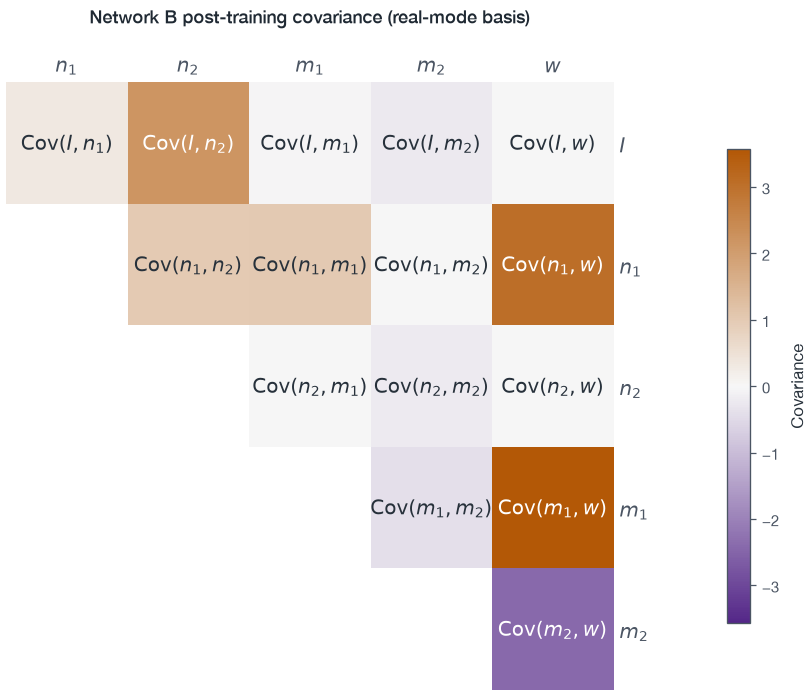

Recurrent overlap nᵀm/N:
 [[ 1.011 -0.   ]
 [-0.    -0.218]]
Post-training input covariances [n₁, n₂]: [0.311 2.202]
Post-training readout covariances [m₁, m₂]: [ 3.57  -2.407]


In [22]:
persistent_vectors = {
    "I": persistent_model.I.detach().numpy(),
    "n_1": persistent_n[:, 0],
    "n_2": persistent_n[:, 1],
    "m_1": persistent_m[:, 0],
    "m_2": persistent_m[:, 1],
    "w": persistent_model.w.detach().numpy(),
}
persistent_names = tuple(persistent_vectors)
(
    persistent_loading_mean,
    persistent_loading_covariance,
) = analysis.fit_loading_gaussian(persistent_vectors)

plotting.plot_connectivity_covariance(
    persistent_names,
    persistent_loading_covariance,
    title="Network B post-training covariance (real-mode basis)",
)
plt.show()

persistent_index = {
    name: index
    for index, name in enumerate(persistent_names)
}
print("Recurrent overlap nᵀm/N:\n", np.round(persistent_overlap, 3))
print(
    "Post-training input covariances [n₁, n₂]:",
    np.round(
        persistent_loading_covariance[
            persistent_index["I"],
            [
                persistent_index["n_1"],
                persistent_index["n_2"],
            ],
        ],
        3,
    ),
)
print(
    "Post-training readout covariances [m₁, m₂]:",
    np.round(
        persistent_loading_covariance[
            [
                persistent_index["m_1"],
                persistent_index["m_2"],
            ],
            persistent_index["w"],
        ],
        3,
    ),
)


#### 2.3.4 Reconstruct Network B three ways

This repeats Network A's three tests with **Network B's own real-mode
post-training Gaussian fit**:

1. ten finite \(N=128\) Gaussian-sampled RNNs;
2. the infinite-population full-covariance Gaussian circuit;
3. the handout diagonal circuit built from only Network B's fitted
   same-mode, input, readout, and variance entries.

All systems are evaluated on the balanced \(7\times7\) frequency grid
at 500, 1000, 1500, and 2000 ms delays. The main score is the worst MSE
across those four delays. The paper initialization coefficients are not
reused here.

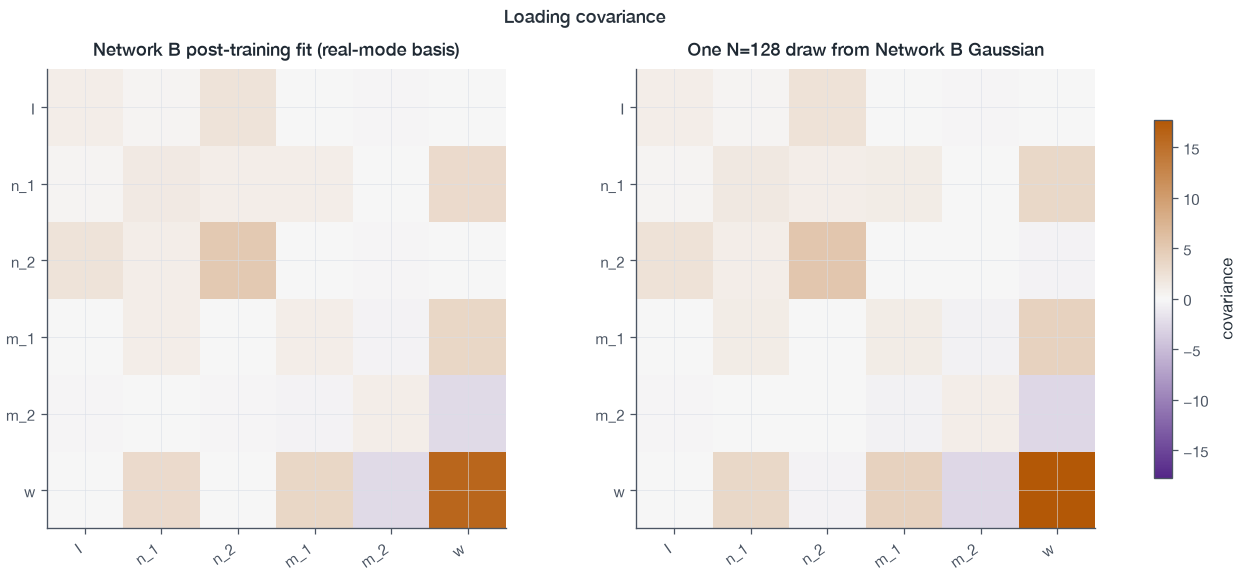

Network B sampled worst-delay MSE, median [range]: 0.1047 [0.0171, 1.1797]
Sampled MSE medians by delay: [0.0526 0.0748 0.0961 0.1047]


In [23]:
(
    persistent_sampled_vectors,
    persistent_sampled_covariance,
) = analysis.sample_loading_vectors(
    persistent_names,
    persistent_loading_mean,
    persistent_loading_covariance,
    num_samples=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 30),
)
plotting.plot_covariance_comparison(
    persistent_names,
    persistent_loading_covariance,
    persistent_sampled_covariance,
    titles=(
        "Network B post-training fit (real-mode basis)",
        "One N=128 draw from Network B Gaussian",
    ),
)
plt.show()

persistent_sampled_networks = analysis.sample_low_rank_rnns(
    persistent_names,
    persistent_loading_mean,
    persistent_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 31),
)
persistent_sampled_mses_by_delay = np.array(
    [
        analysis.variable_delay_mses(
            network,
            memory_grid_pairs,
            probe_delays,
        )
        for network in persistent_sampled_networks
    ]
)
persistent_sampled_worst_mses = (
    persistent_sampled_mses_by_delay.max(axis=1)
)
persistent_sampled_overlap_eigenvalues = np.array(
    [
        np.linalg.eigvals(
            analysis.connectivity_overlap(
                network.m.detach().numpy(),
                network.n.detach().numpy(),
            )
        )
        for network in persistent_sampled_networks
    ]
)

print(
    "Network B sampled worst-delay MSE, median [range]: "
    f"{np.median(persistent_sampled_worst_mses):.4f} "
    f"[{persistent_sampled_worst_mses.min():.4f}, "
    f"{persistent_sampled_worst_mses.max():.4f}]"
)
print(
    "Sampled MSE medians by delay:",
    np.round(
        np.median(persistent_sampled_mses_by_delay, axis=0),
        4,
    ),
)


**Entries from Network B's fitted covariance retained by the handout circuit**

| Retained quantity | Fitted value |
|---|---:|
| `Cov(n_1, m_1)` | 1.0109 |
| `Cov(n_2, m_2)` | -0.2176 |
| `Cov(n_1, I)` | 0.3114 |
| `Cov(n_2, I)` | 2.2016 |
| `Cov(w, m_1)` | 3.5697 |
| `Cov(w, m_2)` | -2.4074 |
| `Cov(m_1, m_1)` | 0.9999 |
| `Cov(m_2, m_2)` | 0.9992 |
| `Cov(I, I)` | 0.9994 |

| Delay (ms) | Source trained RNN MSE | Full-covariance circuit MSE | Handout diagonal circuit MSE | Finite sampled-RNN median MSE |
|---:|---:|---:|---:|---:|
| 500 | 0.0026 | 0.0039 | 0.0061 | 0.0526 |
| 1000 | 0.0027 | 0.0042 | 0.0062 | 0.0748 |
| 1500 | 0.0030 | 0.0047 | 0.0066 | 0.0961 |
| 2000 | 0.0034 | 0.0053 | 0.0070 | 0.1047 |

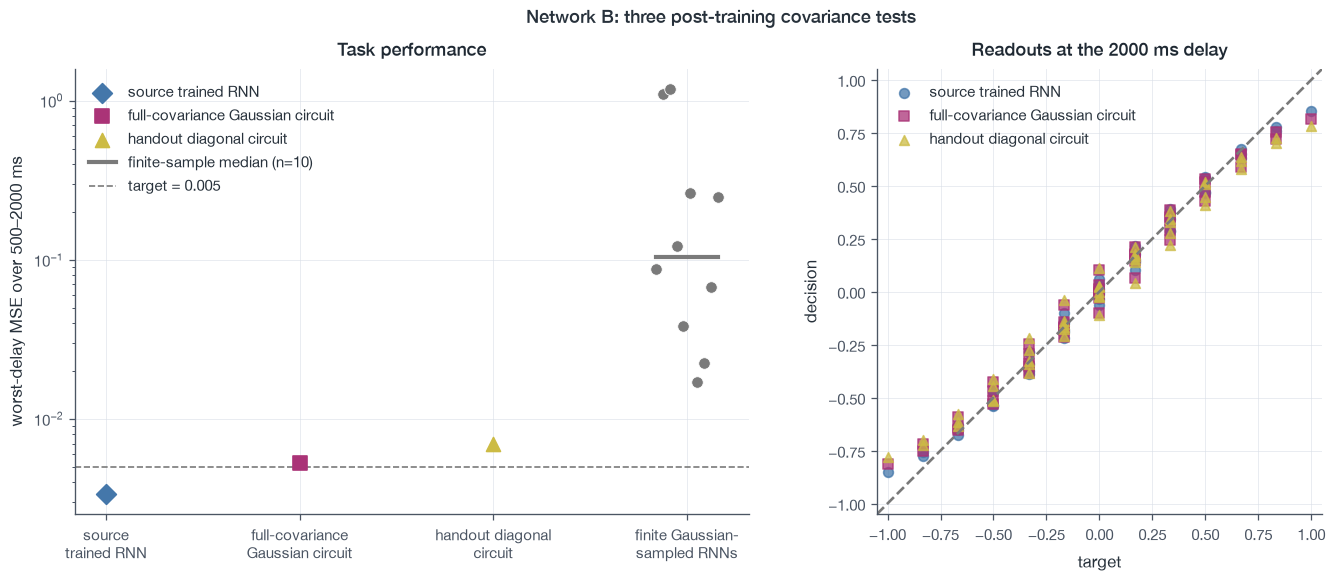

Network B source trained RNN MSE by delay: [0.002558 0.002701 0.003022 0.003382]
Network B full-covariance circuit MSE by delay: [0.003864 0.004158 0.004708 0.005253]
Network B handout diagonal circuit MSE by delay: [0.006146 0.00619  0.006586 0.006982]
Network B handout diagonal circuit R² by delay: [0.976  0.9758 0.974  0.9722]


In [24]:
persistent_reduced_mses = []
persistent_reduced_r2s = []
persistent_reduced_decisions_by_delay = []
persistent_diagonal_mses = []
persistent_diagonal_r2s = []
persistent_diagonal_decisions_by_delay = []

for delay in probe_delays:
    (
        delay_inputs,
        delay_targets,
        delay_decision_mask,
    ) = memory_task.make_variable_delay_trials(
        memory_grid_pairs,
        np.full(len(memory_grid_pairs), delay),
    )
    (
        delay_reduced_outputs,
        delay_reduced_kappa,
        delay_reduced_input,
    ) = mean_field.simulate_gaussian_circuit(
        delay_inputs.numpy(),
        persistent_names,
        persistent_loading_mean,
        persistent_loading_covariance,
        step_size=persistent_model.step_size,
    )
    (
        delay_reduced_mse,
        delay_reduced_r2,
        delay_reduced_decisions,
    ) = analysis.masked_regression_metrics(
        delay_reduced_outputs,
        delay_targets.numpy(),
        delay_decision_mask.numpy(),
    )
    persistent_reduced_mses.append(delay_reduced_mse)
    persistent_reduced_r2s.append(delay_reduced_r2)
    persistent_reduced_decisions_by_delay.append(
        delay_reduced_decisions
    )

    (
        delay_diagonal_outputs,
        delay_diagonal_kappa,
        delay_diagonal_input,
    ) = mean_field.simulate_diagonal_circuit(
        delay_inputs.numpy(),
        persistent_names,
        persistent_loading_covariance,
        step_size=persistent_model.step_size,
    )
    (
        delay_diagonal_mse,
        delay_diagonal_r2,
        delay_diagonal_decisions,
    ) = analysis.masked_regression_metrics(
        delay_diagonal_outputs,
        delay_targets.numpy(),
        delay_decision_mask.numpy(),
    )
    persistent_diagonal_mses.append(delay_diagonal_mse)
    persistent_diagonal_r2s.append(delay_diagonal_r2)
    persistent_diagonal_decisions_by_delay.append(
        delay_diagonal_decisions
    )

persistent_reduced_mses = np.asarray(persistent_reduced_mses)
persistent_reduced_r2s = np.asarray(persistent_reduced_r2s)
persistent_reduced_decisions_by_delay = np.asarray(
    persistent_reduced_decisions_by_delay
)
persistent_diagonal_mses = np.asarray(persistent_diagonal_mses)
persistent_diagonal_r2s = np.asarray(persistent_diagonal_r2s)
persistent_diagonal_decisions_by_delay = np.asarray(
    persistent_diagonal_decisions_by_delay
)

(
    longest_delay_inputs,
    longest_delay_targets,
    longest_delay_mask,
) = memory_task.make_variable_delay_trials(
    memory_grid_pairs,
    np.full(len(memory_grid_pairs), probe_delays[-1]),
)
longest_delay_outputs, _ = analysis.run_model(
    persistent_model,
    longest_delay_inputs,
)
(
    longest_delay_trained_mse,
    longest_delay_trained_r2,
    longest_delay_trained_decisions,
) = analysis.masked_regression_metrics(
    longest_delay_outputs,
    longest_delay_targets.numpy(),
    longest_delay_mask.numpy(),
)
assert np.isclose(
    longest_delay_trained_mse,
    persistent_probe_mses[-1],
)

persistent_diagonal_covariances = analysis.named_covariances(
    persistent_names,
    persistent_loading_covariance,
    diagonal_covariance_pairs,
)
persistent_covariance_rows = "\n".join(
    f"| `{quantity}` | {value:.4f} |"
    for quantity, value in persistent_diagonal_covariances.items()
)
display(
    Markdown(
        "**Entries from Network B's fitted covariance retained by the "
        "handout circuit**\n\n"
        "| Retained quantity | Fitted value |\n"
        "|---|---:|\n"
        + persistent_covariance_rows
    )
)

delay_rows = "\n".join(
    (
        f"| {20 * delay} | {trained_mse:.4f} | "
        f"{reduced_mse:.4f} | {diagonal_mse:.4f} | "
        f"{sample_median:.4f} |"
    )
    for (
        delay,
        trained_mse,
        reduced_mse,
        diagonal_mse,
        sample_median,
    ) in zip(
        probe_delays,
        persistent_probe_mses,
        persistent_reduced_mses,
        persistent_diagonal_mses,
        np.median(persistent_sampled_mses_by_delay, axis=0),
    )
)
display(
    Markdown(
        "| Delay (ms) | Source trained RNN MSE | "
        "Full-covariance circuit MSE | Handout diagonal circuit MSE | "
        "Finite sampled-RNN median MSE |\n"
        "|---:|---:|---:|---:|---:|\n"
        + delay_rows
    )
)

plotting.plot_gaussian_pipeline(
    persistent_probe_mses.max(),
    persistent_reduced_mses.max(),
    persistent_diagonal_mses.max(),
    persistent_sampled_worst_mses,
    longest_delay_targets.numpy(),
    longest_delay_trained_decisions,
    persistent_reduced_decisions_by_delay[-1],
    persistent_diagonal_decisions_by_delay[-1],
    threshold=TASK_MSE_THRESHOLD,
    title="Network B: three post-training covariance tests",
    score_label="worst-delay MSE over 500–2000 ms",
    readout_title="Readouts at the 2000 ms delay",
)
plt.show()

print(
    "Network B source trained RNN MSE by delay:",
    np.round(persistent_probe_mses, 6),
)
print(
    "Network B full-covariance circuit MSE by delay:",
    np.round(persistent_reduced_mses, 6),
)
print(
    "Network B handout diagonal circuit MSE by delay:",
    np.round(persistent_diagonal_mses, 6),
)
print(
    "Network B handout diagonal circuit R² by delay:",
    np.round(persistent_diagonal_r2s, 4),
)

Network B's source RNN solves every tested delay (worst-delay MSE
\(0.0034\)). The full-covariance circuit almost preserves that precision:
its MSE rises from \(0.0039\) at 500 ms to \(0.0053\) at 2000 ms, narrowly
missing the criterion only at the longest delay.

The handout diagonal circuit is less accurate but remains qualitatively
faithful: its MSE is \(0.0061\)–\(0.0070\), with \(R^2=0.9760\)–\(0.9722\).
It misses the strict \(0.005\) criterion at every delay, yet it is far
better than the finite Gaussian RNNs (median worst-delay MSE \(0.1047\)).
This supports the persistent/transient two-mode mechanism while showing
that the complete post-training covariance matters for quantitative
fidelity. The diagonal circuit uses Network B's fitted entries shown
above—not the numerical coefficients used for initialization.

### 2.4 What the two covariance tests show

The two fitted Gaussians come from different trained networks and
different explicit bases: Network A uses its SVD basis because its modes
are complex, whereas Network B uses real persistent/transient modes.
Individual covariance entries are gauge-dependent, so the meaningful
comparison is within each pipeline: does that network's fitted Gaussian
preserve its own dynamics and task behavior?

For each network, the full-covariance and diagonal circuits are
instantiated from the same empirical post-training covariance. Their
difference therefore measures the cost of imposing the handout's
zero-mean, diagonal two-mode assumptions. Neither circuit substitutes
the paper initialization values.

The table below is generated from the executed results. Network B's
score is the worst MSE across the four probe delays; Network A's is its
fixed-delay grid MSE.

In [25]:
oscillatory_sample_successes = int(
    np.sum(oscillatory_sampled_mses < TASK_MSE_THRESHOLD)
)
persistent_sample_successes = int(
    np.sum(
        persistent_sampled_worst_mses
        < TASK_MSE_THRESHOLD
    )
)

rank_two_summary = f'''
| Pipeline | Training protocol | Source trained RNN | Finite Gaussian-sampled RNNs | Full-covariance Gaussian circuit | Handout diagonal circuit | Dynamics |
|---|---|---:|---:|---:|---:|---|
| Network A | fixed delay, random initialization | MSE {oscillatory_mse:.4f} | median MSE {np.median(oscillatory_sampled_mses):.3f}; {oscillatory_sample_successes}/{NUM_GAUSSIAN_NETWORKS} pass | MSE {oscillatory_reduced_mse:.4f} | MSE {oscillatory_diagonal_mse:.4f} | complex rotating modes |
| Network B | randomized delays, paper-informed initialization | worst-delay MSE {persistent_probe_mses.max():.4f} | median worst-delay MSE {np.median(persistent_sampled_worst_mses):.3f}; {persistent_sample_successes}/{NUM_GAUSSIAN_NETWORKS} pass | worst-delay MSE {persistent_reduced_mses.max():.4f} | worst-delay MSE {persistent_diagonal_mses.max():.4f} | real persistent/transient modes |
'''
display(Markdown(rank_two_summary))

validation = {
    "rank1_training_threshold_met": rank1_losses[-1] < 5e-2,
    "network_a_trained_threshold_met": (
        oscillatory_mse < TASK_MSE_THRESHOLD
    ),
    "network_a_sampled_networks_miss_threshold": (
        oscillatory_sampled_mses.min() > TASK_MSE_THRESHOLD
    ),
    "network_a_reduced_circuit_misses_threshold": (
        oscillatory_reduced_mse > TASK_MSE_THRESHOLD
    ),
    "network_a_diagonal_circuit_is_finite": bool(
        np.isfinite(oscillatory_diagonal_outputs).all()
    ),
    "network_a_full_covariance_beats_diagonal": (
        oscillatory_reduced_mse < oscillatory_diagonal_mse
    ),
    "network_b_trained_threshold_met_at_every_delay": (
        persistent_probe_mses.max() < TASK_MSE_THRESHOLD
    ),
    "network_b_sampled_networks_miss_threshold": (
        persistent_sampled_worst_mses.min()
        > TASK_MSE_THRESHOLD
    ),
    "network_b_reduced_circuit_matches_observed_result": (
        persistent_reduced_mses[:-1].max() < TASK_MSE_THRESHOLD
        and persistent_reduced_mses[-1] > TASK_MSE_THRESHOLD
    ),
    "network_b_diagonal_circuit_is_finite": bool(
        np.isfinite(persistent_diagonal_mses).all()
        and np.isfinite(persistent_diagonal_r2s).all()
    ),
    "network_b_diagonal_circuit_misses_threshold": (
        persistent_diagonal_mses.min() > TASK_MSE_THRESHOLD
    ),
    "network_b_full_covariance_beats_diagonal": (
        persistent_reduced_mses.max()
        < persistent_diagonal_mses.max()
    ),
    "network_b_modes_are_real": bool(
        np.isreal(persistent_overlap_values).all()
    ),
    "fixed_vectors_unchanged": bool(
        torch.equal(rank1_model.I, fixed_input_before)
        and torch.equal(rank1_model.w, fixed_readout_before)
    ),
    "network_a_svd_preserves_connectivity": (
        oscillatory_reconstruction_error < 1e-5
    ),
    "rank1_fixed_points_verified": bool(
        len(fixed_points) >= 1
        and np.max(np.abs(fixed_point_residuals)) < 1e-4
    ),
    "network_a_covariance_is_psd": (
        np.linalg.eigvalsh(
            oscillatory_loading_covariance
        ).min() > -1e-8
    ),
    "network_b_covariance_is_psd": (
        np.linalg.eigvalsh(
            persistent_loading_covariance
        ).min() > -1e-8
    ),
}
assert all(validation.values())
validation


| Pipeline | Training protocol | Source trained RNN | Finite Gaussian-sampled RNNs | Full-covariance Gaussian circuit | Handout diagonal circuit | Dynamics |
|---|---|---:|---:|---:|---:|---|
| Network A | fixed delay, random initialization | MSE 0.0008 | median MSE 0.501; 0/10 pass | MSE 0.0180 | MSE 0.9847 | complex rotating modes |
| Network B | randomized delays, paper-informed initialization | worst-delay MSE 0.0034 | median worst-delay MSE 0.105; 0/10 pass | worst-delay MSE 0.0053 | worst-delay MSE 0.0070 | real persistent/transient modes |


{'rank1_training_threshold_met': True,
 'network_a_trained_threshold_met': True,
 'network_a_sampled_networks_miss_threshold': np.True_,
 'network_a_reduced_circuit_misses_threshold': True,
 'network_a_diagonal_circuit_is_finite': True,
 'network_a_full_covariance_beats_diagonal': True,
 'network_b_trained_threshold_met_at_every_delay': np.True_,
 'network_b_sampled_networks_miss_threshold': np.True_,
 'network_b_reduced_circuit_matches_observed_result': np.True_,
 'network_b_diagonal_circuit_is_finite': True,
 'network_b_diagonal_circuit_misses_threshold': np.True_,
 'network_b_full_covariance_beats_diagonal': np.True_,
 'network_b_modes_are_real': True,
 'fixed_vectors_unchanged': True,
 'network_a_svd_preserves_connectivity': True,
 'rank1_fixed_points_verified': True,
 'network_a_covariance_is_psd': np.True_,
 'network_b_covariance_is_psd': np.True_}

## 3. Checks and takeaways

- **Training success and covariance sufficiency are separate
  questions.** Both source RNNs solve their tasks, yet none of the ten
  finite \(N=128\) Gaussian resamples reaches the criterion in either
  pipeline.
- **Network A learns a timed rotation.** Its full-covariance circuit
  retains useful behavior (MSE \(0.0180\)), whereas the handout diagonal
  circuit destroys the computation (MSE \(0.9847\)). The dropped
  cross-mode coupling is essential to this solution.
- **Network B learns persistent/transient dynamics.** Its full-covariance
  and diagonal circuits both track the target across 500–2000 ms. The
  complete circuit is more accurate (worst MSE \(0.0053\) vs \(0.0070\)),
  while the diagonal circuit still attains minimum \(R^2=0.9722\).
- **The two circuit tests are deliberately nested.** The full-covariance
  circuit uses every fitted mean and covariance; the handout circuit uses
  only the nine displayed fitted quantities (six couplings and three
  variances) and zeros the rest.
- **Paper initialization and post-training analysis are not
  interchangeable.** The paper relations initialize Network B. Finite
  sampling and both reduced circuits then use the corresponding trained
  network's empirical fit.
- **The diagonal model is basis-dependent.** It is a poor description of
  Network A's rotating SVD modes and a useful approximation in Network
  B's real persistent/transient basis. Comparing task fidelity within
  each named basis is more meaningful than subtracting raw covariance
  entries across networks.